# Generalized E3SMLE and CESM-SMYLE Global RMSE Skill Maps

This notebook computes and plots seasonal skill for `TREFHT`, `PRECT`, or `PSL` using the same workflow.

Change only one line in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "PRECT" # precipitation
# field = "PSL"   # sea-level pressure
```

Variable-specific observation product, observation variable name, unit conversion, labels, and cache filenames are handled through `VAR_CONFIG`.


For a fresh or source-validating run, keep `cache.source_identity_mode="inventory"`
and `prepared_skill.mode="auto"`. After that run creates every prepared anomaly and
observation input, an archive-free restart uses `cache.source_identity_mode="snapshot"`
with `prepared_skill.mode="require"`; this fails early if any signed inventory
snapshot or prepared input is missing or incompatible.


In [78]:
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path

# Ensure repository root is on sys.path so top-level packages (like workflows) are importable
_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = (
    [Path(_repo_override).expanduser().resolve()]
    if _repo_override
    else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
)
REPO_ROOT = next((p for p in _repo_candidates if (p / "workflows").is_dir()), None)
if REPO_ROOT and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import data_access_cesm_smyle as smyle_access
from esp_lab import stats
from esp_lab.leadtime_prepared_cache import (
    build_prepared_skill_dataset, cache_status, expected_prepared_skill_attrs,
    open_prepared_skill_dataset, prepared_skill_cache_status,
    prepared_skill_path, write_prepared_skill_dataset,
)
from esp_lab.leadtime_skill_cache import (
    SkillComparisonCacheLayout, cache_comparison_anomaly,
    expected_skill_cache_attrs, file_inventory_digest,
    generate_member_indices, load_or_write_member_selection,
    member_selection_attrs, source_fingerprint, stable_resampling_seed,
)
from esp_lab.leadtime_validation import check_remove_drift_sample
from esp_lab.leadtime_workflow import resolve_source_revision
from esp_lab.leadtime_plot_utils import seasonal_label, style_global_map_axis

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.filename_utils import figure_filename
from esp_lab.utils.netcdf_utils import atomic_to_netcdf, load_netcdf
from esp_lab.utils.resource_utils import ResourceTracker
from esp_lab.utils.unit_conversion import (
    convert_kelvin_to_celsius, convert_pa_to_hpa,
    convert_precip_mps_to_mmday, no_unit_conversion,
)
from workflows.leadtime_skill import rmse_comparison as rmse_utils

from esp_lab.utils.dask_util import DaskConfig, get_cluster_client, close_cluster


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [79]:
import dask
from dask.distributed import (
    wait,
    get_client
)

from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

machine_env = os.environ.get('CLUSTER_TYPE', 'local')
# Four 4-GB workers fit the shared-login safety cap and avoid a misleading
# 30-worker request that the cluster helper would silently reduce.
dask_workers = 4

dask_cfg = DaskConfig(
    cluster_type=machine_env, workers=dask_workers, memory_limit="4GB"
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(), lambda: get_cluster_client(dask_cfg)
)

dask.__version__



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:40369
Connected workers: 4
Dashboard: http://127.0.0.1:8787/status


'2026.3.0'

2026-09-11 18:17:04,820 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fea08c1593fcb3879d3ae77af8f97345 initialized by task ('rechunk-merge-rechunk-transfer-2ac0969c8ccf918b062a024399d6dfe6', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:42645
2026-09-11 18:17:14,096 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fea08c1593fcb3879d3ae77af8f97345 deactivated due to stimulus 'task-finished-1789175834.0955646'
2026-09-11 18:17:14,611 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e02835ef109ded81568a04fd2d553d54 initialized by task ('rechunk-merge-rechunk-transfer-c57dc300ab1814b62fb80251c748ec66', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:34957
2026-09-11 18:17:19,217 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e02835ef109ded81568a04fd2d553d54 deactivated due to stimulus 'task-finished-1789175839.2165205'
2026-09-11 18:17:43,165 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 73fb

In [80]:
cluster

LocalCluster(636b177f, 'tcp://127.0.0.1:40369', workers=4, threads=4, memory=14.90 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [81]:
%%time
# ===== FIELD AND VARIABLE CONFIGURATION =====
# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
field = "TREFHT"
#field = "PRECT"
#field = "PSL"

# Optional common processing end year. None uses the end year from
# run.initialization_years.
YEAR_END = 2011  # None

# Which E3SM case should old single-case cells/variables point to
E3SM_REFERENCE_CASE = "E3SM-FOSIRL"

# ===== ENSEMBLE AND HINDCAST PARAMETERS =====
case_nens = 10
case_nlead = 24
engine = "netcdf4"

# =============================================================================
# CONFIGURATION BLOCK: Edit settings here
# =============================================================================
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# ===== DIRECTORY AND PATHS CONFIGURATION =====
# Directory setup
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR

# Clean model-first diagnostic layout helpers.
# E3SMLE_DIAG_DIR is kept as a backwards-compatible variable name, but it now
# points to the S2D diagnostic root; each case lives under its cache_tag.
E3SM_DIAG_ROOT = Path(E3SMLE_OUTDIR)

def e3sm_case_dir(case_info):
    return E3SM_DIAG_ROOT / case_info["cache_tag"]

def e3sm_leadtime_dir(case_info, stage, *parts):
    path = e3sm_case_dir(case_info) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path

def smyle_leadtime_dir(stage, *parts):
    path = Path(CESM_SMYLE_OUTDIR) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path

FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


# Post-processed data directory candidates
DATA_DIR_CANDIDATES = [
    "/global/cfs/cdirs/e3sm/S2S2D/post_process",
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]
DATA_DIR = "/global/cfs/cdirs/e3sm/S2S2D/post_process"

# Central run controls mirror the finalized 1a architecture. Every later
# stage consumes these values; case/month caches can therefore restart independently.
WORKFLOW_SETTINGS = {
    'paths': {
        's2d_diag_root': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag',
        'figure_outdir': '/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag',
        'e3sm_data_dir': '/global/cfs/cdirs/e3sm/S2S2D/post_process',
        'obs_data_dir': '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series',
    },
    'run': {'smoke_mode': False, 'initialization_years': (1980, 2018 if YEAR_END is None else int(YEAR_END)),
            'year_end': YEAR_END, 'years': (1980, 2018 if YEAR_END is None else int(YEAR_END)),
            'exclude_year': None,
            'init_months': [5, 11], 'climatology_years': (1981, 2010)},
    'regrid': {
        'target_dlat': 5.0,
        'target_dlon': 5.0,
        'method': 'conservative',
        'periodic': True,
    },
    'cache': {'source_identity_mode': 'inventory', 'force_rewrite_inputs': False,
              'force_compute_skill': False, 'force_compute_comparison': False,
              'cleanup_temp_files': True, 'temp_file_max_age_hours': 24.0},
    # Preserve the notebook's established no-linear-detrend metric while making
    # the primary and resampling calculations use the same choice.
    'prepared_skill': {'mode': 'auto', 'force_recompute': False},
    'skill': {'detrend': False, 'lead_start': 1, 'lead_end': 8},
    'significance': {'mode': 'final', 'iterations': 100, 'random_seed': 42,
                     'alpha': 0.1, 'iteration_batch_size': 10},
}
if WORKFLOW_SETTINGS['run']['smoke_mode']:
    WORKFLOW_SETTINGS['run'].update(years=(1980, 1984), init_months=[11],
                                    climatology_years=(1980, 1984))
    WORKFLOW_SETTINGS['significance'].update(mode='test', iterations=3)
    WORKFLOW_SETTINGS['regrid'].update(target_dlat=5.0, target_dlon=5.0)
S2D_DIAG_ROOT = Path(WORKFLOW_SETTINGS['paths']['s2d_diag_root'])
DATA_DIR = WORKFLOW_SETTINGS['paths']['e3sm_data_dir']
FIGURE_OUTDIR = Path(WORKFLOW_SETTINGS['paths']['figure_outdir'])
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# Common target grid for regridding and cache identification
target_dlat = WORKFLOW_SETTINGS['regrid']['target_dlat']
target_dlon = WORKFLOW_SETTINGS['regrid']['target_dlon']
regrid_method = WORKFLOW_SETTINGS['regrid']['method']
regrid_periodic = WORKFLOW_SETTINGS['regrid']['periodic']
target_grid_identity = f"latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}"
destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)

# Stable output names: rerunning a field replaces its previous figures.
FIGURE_FILENAMES = {
    "global": f"fig_2a_{field.lower()}_rmse_global.png",
    "conus": f"fig_2a_{field.lower()}_rmse_conus.png",
    "difference": f"fig_2a_{field.lower()}_rmse_difference.png",
}

# Unit conversions are imported from esp_lab.utils.unit_conversion.
# ===== VARIABLE CONFIGURATION =====
VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": convert_precip_mps_to_mmday,
        "smyle_convert": convert_precip_mps_to_mmday,
        # GPCP PRECT from this archive is already mm/day.
        "obs_convert": lambda da: no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_pa_to_hpa,
        "smyle_convert": convert_pa_to_hpa,
        "obs_convert": convert_pa_to_hpa,
        "units": "hPa",
    },
}

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]

# Field-specific map colorbar configuration
MAP_COLORBAR_CONFIG = {
    "absolute_rmse": {
        "TREFHT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                   "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PRECT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                  "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PSL": {"levels": [0, 2, 4, 6, 8, 10, 12],
                "ticks": [0, 2, 4, 6, 8, 10, 12], "decimals": 1},
    },
    "normalized_rmse_difference": {
        "TREFHT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                              -0.2, -0.15, -0.1, -0.05, 0,
                              0.05, 0.1, 0.15, 0.2, 0.25,
                              0.3, 0.35, 0.4, 0.45, 0.5],
                   "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PRECT": {"levels": [-0.5, -0.45, -0.4, -0.35, -0.3, -0.25,
                             -0.2, -0.15, -0.1, -0.05, 0,
                             0.05, 0.1, 0.15, 0.2, 0.25,
                             0.3, 0.35, 0.4, 0.45, 0.5],
                  "ticks": [-0.5, -0.25, 0, 0.25, 0.5], "decimals": 2},
        "PSL": {"levels": [-0.6, -0.5, -0.4, -0.3, -0.2, -0.1,
                           0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
                "ticks": [-0.6, -0.3, 0, 0.3, 0.6], "decimals": 1},
    },
}

def map_colorbar_settings(plot_type, field):
    config = MAP_COLORBAR_CONFIG[plot_type][field]
    levels = np.asarray(config["levels"], dtype=float)
    ticks = np.asarray(config["ticks"], dtype=float)
    steps = np.diff(levels)
    if levels.ndim != 1 or levels.size < 2 or np.any(steps <= 0):
        raise ValueError(f"Invalid colorbar levels for {plot_type}/{field}")
    if not np.allclose(steps, steps[0]):
        raise ValueError(
            f"Map helper requires uniform levels for {plot_type}/{field}"
        )
    if np.any(ticks < levels[0]) or np.any(ticks > levels[-1]):
        raise ValueError(f"Ticks outside levels for {plot_type}/{field}")
    return levels, ticks, int(config["decimals"])

rmse_levels, rmse_ticks, rmse_decimals = map_colorbar_settings(
    "absolute_rmse", field
)
nrmse_diff_levels, nrmse_diff_ticks, nrmse_diff_decimals = map_colorbar_settings(
    "normalized_rmse_difference", field
)

print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")
print(f"Using post-processed data directory: {DATA_DIR}")

# ===== MULTI-CASE E3SM HINDCAST CONFIGURATION =====
# Add more entries here as new post-processed hindcasts land under DATA_DIR
E3SM_CASES = {
    "E3SM-FOSIRL": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
        "source_revision": "post_process_v1",
    },
    "E3SM-Reanalysis": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
        "source_revision": "post_process_v1",
    },
    "E3SM-4DEnVarOcn": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "cache_tag": "4DEnVarOcn",
        "display_name": "E3SMv3-4DEnVarOcn",
        "source_revision": "post_process_v1",
    },
}

RUN = WORKFLOW_SETTINGS['run']
run_year_start, run_year_end = map(int, RUN.get('initialization_years', RUN['years']))
configured_year_end = RUN.get('year_end')
effective_year_end = run_year_end if configured_year_end is None else int(configured_year_end)
years, yeare = run_year_start, effective_year_end
if "E3SM-4DEnVarOcn" in E3SM_CASES and yeare > 2011:
    raise ValueError(
        f"E3SM-4DEnVarOcn only spans 1980-2011. For multi-model comparison with 4DEnVar, "
        f"set YEAR_END = 2011 or remove 'E3SM-4DEnVarOcn' from E3SM_CASES."
    )
yexcl = WORKFLOW_SETTINGS['run']['exclude_year']

# Shared climatology window for drift removal, skill calculation, and checks
climy0, climy1 = WORKFLOW_SETTINGS['run']['climatology_years']
init_months = list(WORKFLOW_SETTINGS['run']['init_months'])

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]
INIT_YEARS_BY_MONTH = {init_month: lead_years for init_month in init_months}

# Discovery settings are declared before provenance inventory and reused below.
members = [f'EN{i:02d}' for i in range(case_nens)]
realm, grid, freq, ts_split = 'atm', '180x360_aave', 'monthly', '2yr'
require_all_members = verify_field_name = verify_coverage = True
source_identity_mode = WORKFLOW_SETTINGS['cache']['source_identity_mode']
prepared_mode = WORKFLOW_SETTINGS['prepared_skill']['mode']
prepared_force_recompute = WORKFLOW_SETTINGS['prepared_skill']['force_recompute']
if source_identity_mode not in {'inventory', 'snapshot', 'revision'}:
    raise ValueError("cache.source_identity_mode must be inventory, snapshot, or revision")
if prepared_mode not in {'auto', 'rebuild', 'require'}:
    raise ValueError("prepared_skill.mode must be auto, rebuild, or require")
if source_identity_mode == 'snapshot' and prepared_mode != 'require':
    raise ValueError("Snapshot mode requires prepared_skill.mode='require'")
if prepared_mode == 'require' and prepared_force_recompute:
    raise ValueError("prepared_skill.force_recompute cannot be used with mode='require'")

snapshot_dir = S2D_DIAG_ROOT / 'source_inventory_snapshots'
def resolved_revision(configured_revision, paths, root, identity):
    return resolve_source_revision(
        source_identity_mode, configured_revision, identity=identity,
        snapshot_dir=snapshot_dir, paths=paths, root=root)

e3sm_source_identity_by_case_month = {}
for case_key, case_info in E3SM_CASES.items():
    e3sm_source_identity_by_case_month[case_key] = {}
    for init_month in init_months:
        identity = {
            'archive_root': str(DATA_DIR), 'case_prefix': case_info['case_prefix'],
            'field': field, 'init_month': init_month,
            'requested_years': [int(y) for y in INIT_YEARS_BY_MONTH[init_month]],
            'members': members, 'lead_count': case_nlead, 'frequency': freq,
        }
        paths = []
        if source_identity_mode == 'inventory':
            tags = data_access.build_init_tags(INIT_YEARS_BY_MONTH[init_month], init_month)
            nested, valid_tags = data_access.nested_file_list_by_init(
                data_dir=DATA_DIR, case_prefix=case_info['case_prefix'], members=members,
                init_tags=tags, field=field, realm=realm, grid=grid, freq=freq,
                ts_split=ts_split, require_all_members=require_all_members,
                verify_field_name=verify_field_name, verify_coverage=verify_coverage,
                nlead=case_nlead)
            if valid_tags != tags:
                raise FileNotFoundError(
                    f'Incomplete inventory for {case_key}, month {init_month:02d}')
            paths = [path for group in nested for path in group]
        revision = resolved_revision(
            case_info['source_revision'], paths, DATA_DIR, identity)
        e3sm_source_identity_by_case_month[case_key][init_month] = source_fingerprint(
            identity, source_revision=revision)

smyle_source_identity_by_month = {}
for init_month in init_months:
    identity = {
        'benchmark_root': str(SMYLE_BENCHMARK_DIR), 'field': field,
        'init_month': init_month, 'ensemble_member_count': 20,
        'lead_count': 24, 'frequency': 'seas',
        'requested_years': [int(y) for y in INIT_YEARS_BY_MONTH[init_month]],
    }
    paths = []
    if source_identity_mode == 'inventory':
        paths = [smyle_access.benchmark_path(
            field, init_month, SMYLE_BENCHMARK_DIR, nens=20, nlead=24, freq='seas')]
    revision = resolved_revision('benchmark_v1', paths, SMYLE_BENCHMARK_DIR, identity)
    smyle_source_identity_by_month[init_month] = source_fingerprint(
        identity, source_revision=revision)

obs_identity = {
    'archive_root': WORKFLOW_SETTINGS['paths']['obs_data_dir'],
    'product': cfg['obs_name'], 'variable': cfg['obs_var'],
    'archive_years': [cfg['obs_ys'], cfg['obs_ye']],
}
obs_paths = []
if source_identity_mode == 'inventory':
    obs_paths = [obs_access.find_obs_file(
        WORKFLOW_SETTINGS['paths']['obs_data_dir'], cfg['obs_name'], cfg['obs_var'])]
obs_revision = resolved_revision(
    'obs_archive_v1', obs_paths, WORKFLOW_SETTINGS['paths']['obs_data_dir'], obs_identity)
obs_source_identity = source_fingerprint(obs_identity, source_revision=obs_revision)

def e3sm_seasonal_cache_spec(case_key, init_month):
    case_info = E3SM_CASES[case_key]
    cache_tag = case_info['cache_tag']
    year_token = f'y{lead_years[0]}-{lead_years[-1]}_ny{len(lead_years)}'
    path = e3sm_leadtime_dir(case_info, 'inputs', field) / (
        f'{cache_tag}_{init_month:02d}_{field}_{year_token}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc')
    attrs = {
        'cache_kind': 'seasonal_e3sm_input_v2', 'source': cache_tag,
        'source_data_identity': e3sm_source_identity_by_case_month[case_key][init_month],
        'case_prefix': case_info['case_prefix'], 'variable': field,
        'initialization_month': int(init_month),
        'requested_years': ','.join(map(str, INIT_YEARS_BY_MONTH[init_month])),
        'ensemble_member_count': int(case_nens), 'lead_count': int(case_nlead),
    }
    return path, attrs

def prepared_cache_spec(source, init_month, *, case_prefix, source_identity, ensemble_size, requested_years=None):
    provenance = dict(
        source_data_identity=source_identity, case_prefix=case_prefix,
        requested_years=(requested_years if requested_years is not None else INIT_YEARS_BY_MONTH[init_month]),
        target_grid=target_grid_identity, regridding_method=regrid_method,
        ensemble_member_count=ensemble_size, lead_count=case_nlead // 3,
        unit_conversion_version='leadtime_rmse_units_v1')
    path = prepared_skill_path(
        source, 'atm', field, init_month, (climy0, climy1),
        root=S2D_DIAG_ROOT, **provenance)
    expected = expected_prepared_skill_attrs(
        source=source, component='atm', variable=field, init_month=init_month,
        climatology_years=(climy0, climy1), **provenance)
    return path, expected

prepared_specs_by_case_month = {
    case_key: {
        month: prepared_cache_spec(
            info['cache_tag'], month, case_prefix=info['case_prefix'],
            source_identity=e3sm_source_identity_by_case_month[case_key][month],
            ensemble_size=case_nens)
        for month in init_months
    }
    for case_key, info in E3SM_CASES.items()
}
smyle_prepared_specs_by_month = {
    month: prepared_cache_spec(
        'CESM-SMYLE', month, case_prefix='b.e21.BSMYLE.f09_g17',
        source_identity=smyle_source_identity_by_month[month],
        ensemble_size=20, requested_years=INIT_YEARS_BY_MONTH[month])
    for month in init_months
}
all_prepared_specs = [
    spec for by_month in prepared_specs_by_case_month.values()
    for spec in by_month.values()
] + list(smyle_prepared_specs_by_month.values())
missing_prepared = [
    (path, reason) for path, expected in all_prepared_specs
    for compatible, reason in [prepared_skill_cache_status(path, expected_attrs=expected)]
    if not compatible
]
if prepared_mode == 'require' and missing_prepared:
    details = '\n'.join(f'  - {path}: {reason}' for path, reason in missing_prepared)
    raise RuntimeError(f'Required prepared skill inputs are unavailable:\n{details}')
def needs_preparation(spec):
    compatible, _ = prepared_skill_cache_status(spec[0], expected_attrs=spec[1])
    return prepared_force_recompute or prepared_mode == 'rebuild' or not compatible

e3sm_months_to_prepare = {
    case: [month for month, spec in by_month.items() if needs_preparation(spec)]
    for case, by_month in prepared_specs_by_case_month.items()
}
smyle_months_to_prepare = [
    month for month, spec in smyle_prepared_specs_by_month.items()
    if needs_preparation(spec)
]
use_prepared_skill_inputs = (
    not any(e3sm_months_to_prepare.values()) and not smyle_months_to_prepare
)
e3sm_months_to_load_raw = {
    case_key: [month for month in e3sm_months_to_prepare[case_key] if (
        WORKFLOW_SETTINGS['cache']['force_rewrite_inputs'] or not cache_status(
            e3sm_seasonal_cache_spec(case_key, month)[0],
            expected_attrs=e3sm_seasonal_cache_spec(case_key, month)[1],
            required_variables=(field,))[0])]
    for case_key in E3SM_CASES
}
print('Prepared E3SM inputs to build:', e3sm_months_to_prepare)
print('Prepared CESM-SMYLE inputs to build:', smyle_months_to_prepare)
print('Raw E3SM case/month inputs required:', e3sm_months_to_load_raw)
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"

require_all_members = True
verify_field_name = True
verify_coverage = True
debug = True

# Optional: safer open-time chunking
chunks_open = {}  # {"L": 24} can be used if needed

mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

# ===== END CONFIGURATION BLOCK =====

if use_prepared_skill_inputs:
    print('All prepared model inputs are valid; skipping raw E3SM archive access.')
else:
    e3sm_raw_by_case_month = {}

    for case_key, case_info in E3SM_CASES.items():
        case_prefix = case_info["case_prefix"]
        e3sm_raw_by_case_month[case_key] = {}

        print("")
        print("=" * 80)
        print(f"Loading {case_key}: {case_prefix}")

        for init_month in e3sm_months_to_load_raw[case_key]:
            init_tags = data_access.build_init_tags(INIT_YEARS_BY_MONTH[init_month], init_month)

            e3sm = data_access.get_monthly_data(
                data_dir=DATA_DIR,
                case_prefix=case_prefix,
                members=members,
                init_tags=init_tags,
                field=field,
                nlead=case_nlead,
                chunks=chunks_open,
                realm=realm,
                grid=grid,
                freq=freq,
                ts_split=ts_split,
                require_all_members=require_all_members,
                verify_field_name=verify_field_name,
                verify_coverage=verify_coverage,
                engine=engine,
            )

            print(f"{case_key} init_month={init_month}, size={e3sm.nbytes / 1e9:.2f} GB")

            # Apply final chunking after combine
            e3sm = e3sm.chunk(mchunk)

            if debug:
                print(e3sm)
                print(e3sm.dims)
                print(e3sm.Y.values)
                print(e3sm.L.values[:5], e3sm.L.values[-5:])
                print(e3sm.time.isel(Y=0, L=slice(0, 3)).values)

            e3sm_raw_by_case_month[case_key][init_month] = workflow_resources.track(e3sm)

    # Backward-compatible aliases for older exploratory cells
    e3smle_by_month = e3sm_raw_by_case_month[E3SM_REFERENCE_CASE]
    e3smle05 = e3smle_by_month.get(5)


Selected field: TREFHT (2-m air temperature)
Observation product: ERA5 variable=tas
Using post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process
Prepared E3SM inputs to build: {'E3SM-FOSIRL': [5, 11], 'E3SM-Reanalysis': [5, 11], 'E3SM-4DEnVarOcn': [5, 11]}
Prepared CESM-SMYLE inputs to build: [5, 11]
Raw E3SM case/month inputs required: {'E3SM-FOSIRL': [5, 11], 'E3SM-Reanalysis': [5, 11], 'E3SM-4DEnVarOcn': [5, 11]}

Loading E3SM-FOSIRL: WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
E3SM-FOSIRL init_month=5, size=1.99 GB
<xarray.Dataset> Size: 2GB
Dimensions:  (Y: 32, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * Y        (Y) <U10 1kB '1980050100' '1981050100' ... '2011050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.

### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [82]:
%%time
if use_prepared_skill_inputs:
    print('Using prepared skill inputs; skipping seasonal E3SM cache stage.')
else:
    # Store seasonal E3SM datasets to disk for quicker processing next time.
    # Files are stored under <case>/leadtime_acc/inputs/atm/<field>/.

    debug = False #True
    force_rewrite = WORKFLOW_SETTINGS['cache']['force_rewrite_inputs']
    seasonal_write_options = {
        'cleanup_temporary': WORKFLOW_SETTINGS['cache']['cleanup_temp_files'],
        'temp_file_max_age_hours': WORKFLOW_SETTINGS['cache']['temp_file_max_age_hours'],
    }
    encoding = {
        field: {
            "chunksizes": (1, 8, 1, 90, 180),
            "zlib": True,
            "complevel": 1
        }
    }

    e3sm_seas_by_case_month = {}

    for case_key, case_info in E3SM_CASES.items():
        cache_tag = case_info["cache_tag"]
        input_dir = e3sm_leadtime_dir(case_info, "inputs", field)
        input_dir.mkdir(parents=True, exist_ok=True)
        e3sm_seas_by_case_month[case_key] = {}

        for init_month in init_months:
            outfile, seasonal_attrs = e3sm_seasonal_cache_spec(case_key, init_month)
            compatible, reason = cache_status(
                outfile, expected_attrs=seasonal_attrs, required_variables=(field,))

            if compatible and not force_rewrite:
                e3sm_seas = workflow_resources.track(xr.open_dataset(outfile, chunks=mchunk))
            else:
                print(f'Recomputing {outfile}: {reason}')
                e3sm = e3sm_raw_by_case_month[case_key][init_month]

                # 1. seasonal aggregation (lazy)
                e3sm_seas = cal.mon_to_seas_dask(e3sm)

                # 2. rechunk after rolling
                e3sm_seas = e3sm_seas.chunk(mchunk)

                # 3. Stream the lazy result to disk; persisting the complete
                # seasonal archive can exhaust the four-worker memory budget.
                # 4. write with encoding
                print(f"Writing {outfile}")
                e3sm_seas.attrs.update(seasonal_attrs)
                atomic_to_netcdf(
                    e3sm_seas, outfile, encoding=encoding, **seasonal_write_options
                )

                # 5. reopen from disk to keep graph small
                e3sm_seas = workflow_resources.track(xr.open_dataset(outfile, chunks=mchunk))

            e3sm_seas_by_case_month[case_key][init_month] = e3sm_seas

            if debug:
                print(f"\n{case_key} init_month={init_month}")
                print(e3sm_seas)
                print(e3sm_seas.dims)
                print(e3sm_seas.Y.values)
                print(e3sm_seas.L.values[:5], e3sm_seas.L.values[-5:])
                print(e3sm_seas.time.isel(Y=0, L=slice(0, 3)).values)

    # Backward-compatible aliases.
    e3smle_seas_by_month = e3sm_seas_by_case_month[E3SM_REFERENCE_CASE]
    e3smle05_seas = e3smle_seas_by_month.get(5)
    e3smle11_seas = e3smle_seas_by_month.get(11)

    if debug:
        print("available seasonal E3SM cases:", sorted(e3sm_seas_by_case_month))
        print("available seasonal init months:", sorted(e3smle_seas_by_month))




    # Memory cleanup: delete raw monthly data which is no longer needed
    import gc
    try:
        del e3sm_raw_by_case_month
        del e3smle_by_month
        del e3smle05
        del e3smle11
    except NameError:
        pass
    gc.collect()


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/inputs/atm/TREFHT/JRA55_FOSIRL_05_TREFHT_y1980-2011_ny32_N10_M24_seas.nc: file does not exist
Writing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/inputs/atm/TREFHT/JRA55_FOSIRL_05_TREFHT_y1980-2011_ny32_N10_M24_seas.nc
Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/inputs/atm/TREFHT/JRA55_FOSIRL_11_TREFHT_y1980-2011_ny32_N10_M24_seas.nc: file does not exist
Writing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/inputs/atm/TREFHT/JRA55_FOSIRL_11_TREFHT_y1980-2011_ny32_N10_M24_seas.nc
Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/inputs/atm/TREFHT/Reanalysis_05_TREFHT_y1980-2011_ny32_N10_M24_seas.nc: file does not exist
Writing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/inputs/atm/TREFHT/Reanalysis_05_TREFHT_y1980-2011_ny32_N10_M24_seas.nc
Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/le

### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [83]:
%%time
# =============================================================================
# Setup parameters: Regrid & target grid configuration
# =============================================================================
target_dlat = WORKFLOW_SETTINGS["regrid"]["target_dlat"]
target_dlon = WORKFLOW_SETTINGS["regrid"]["target_dlon"]
regrid_method = WORKFLOW_SETTINGS["regrid"]["method"]
regrid_periodic = WORKFLOW_SETTINGS["regrid"]["periodic"]
target_grid_identity = f"latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}"
destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)

# Initialize container dictionaries for regridded data and valid times
e3sm_da_by_case_month = {}
time_by_case_month = globals().get("time_by_case_month", {case_key: {} for case_key in E3SM_CASES})
for case_key in E3SM_CASES:
    time_by_case_month.setdefault(case_key, {})

# Identify missing E3SM case/month pairs needing regridding
missing_e3sm_pairs = [
    (case_key, month)
    for case_key, months in e3sm_months_to_prepare.items()
    for month in months
]

if use_prepared_skill_inputs or not missing_e3sm_pairs:
    print("Using prepared skill inputs; skipping E3SM regridding stage.")
else:
    # Regrid all E3SM hindcast data to the common analysis grid.
    # Ensure clean chunking before regrid.
    e3sm_seas_by_case_month = {
        case_key: {
            init_month: ds.chunk(mchunk)
            for init_month, ds in by_month.items()
        }
        for case_key, by_month in globals().get("e3sm_seas_by_case_month", {}).items()
    }

    # Build one regridder from the first missing case/month.
    _ref_case, _ref_month = missing_e3sm_pairs[0]
    regridder = regrid.make_regridder(
        e3sm_seas_by_case_month[_ref_case][_ref_month],
        destgrid,
        method=regrid_method,
        periodic=regrid_periodic,
    )

    # Regrid, rechunk, and apply variable-specific unit conversion by case/init month.
    for case_key, months in e3sm_months_to_prepare.items():
        if not months:
            continue
        e3sm_da_by_case_month[case_key] = {}

        for init_month in months:
            da = regridder(e3sm_seas_by_case_month[case_key][init_month][field]).chunk(mchunk)
            da = cfg["model_convert"](da)
            e3sm_da_by_case_month[case_key][init_month] = da

            # Preserve seasonal valid times before releasing the source datasets.
            time_by_case_month[case_key][init_month] = (
                e3sm_seas_by_case_month[case_key][init_month].time.load()
            )

            print(f"{case_key} init_month={init_month}")
            print(da.shape)
            print(da.dims)
            print(da.Y.values)
            print(da.L.values[:5], da.L.values[-5:])
            print("units:", da.attrs.get("units"))

    # Memory cleanup: delete seasonal aggregate files which are now regridded
    import gc
    try:
        del e3sm_seas_by_case_month
        del e3smle_seas_by_month
        del e3smle05_seas
        del e3smle11_seas
    except NameError:
        pass
    gc.collect()

# Backward-compatible convenience variables for exploratory cells.
e3smle_da_by_month = e3sm_da_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_da = e3smle_da_by_month.get(5)
e3smle11_da = e3smle_da_by_month.get(11)

time_by_month = time_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)


E3SM-FOSIRL init_month=5
(32, 8, 10, 37, 72)
('Y', 'L', 'M', 'lat', 'lon')
['1980050100' '1981050100' '1982050100' '1983050100' '1984050100'
 '1985050100' '1986050100' '1987050100' '1988050100' '1989050100'
 '1990050100' '1991050100' '1992050100' '1993050100' '1994050100'
 '1995050100' '1996050100' '1997050100' '1998050100' '1999050100'
 '2000050100' '2001050100' '2002050100' '2003050100' '2004050100'
 '2005050100' '2006050100' '2007050100' '2008050100' '2009050100'
 '2010050100' '2011050100']
[ 3  6  9 12 15] [12 15 18 21 24]
units: $^\circ$C
E3SM-FOSIRL init_month=11
(32, 8, 10, 37, 72)
('Y', 'L', 'M', 'lat', 'lon')
['1980110100' '1981110100' '1982110100' '1983110100' '1984110100'
 '1985110100' '1986110100' '1987110100' '1988110100' '1989110100'
 '1990110100' '1991110100' '1992110100' '1993110100' '1994110100'
 '1995110100' '1996110100' '1997110100' '1998110100' '1999110100'
 '2000110100' '2001110100' '2002110100' '2003110100' '2004110100'
 '2005110100' '2006110100' '2007110100' '200

### Load CESM-SMYLE benchmark data
- Benchmark files are pre-generated once by `scripts/run_process_cesm_smyle_benchmark.py` and stored under `<S2D_DIAG_ROOT>/CESM-SMYLE/leadtime_acc/inputs/atm/<field>/`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [84]:
%%time
# =============================================================================
# Setup parameters: CESM-SMYLE benchmark configuration
# =============================================================================
smyle_benchmark_dir = Path(SMYLE_BENCHMARK_DIR)
smyle_nens = 20
smyle_nlead = 24
mchunk_smyle = {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144}

smyle_da_by_month = {}
smyle_time_by_month = globals().get("smyle_time_by_month", {})

if use_prepared_skill_inputs or not smyle_months_to_prepare:
    print("Using prepared skill inputs; skipping CESM-SMYLE archive and regridding stage.")
else:
    # Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
    from esp_lab import data_access_cesm_smyle as smyle_access

    smyle_seas_by_month = {}
    for init_month in smyle_months_to_prepare:
        ds = smyle_access.load_benchmark(
            field=field,
            init_month=init_month,
            benchmark_dir=smyle_benchmark_dir,
            nens=smyle_nens,
            nlead=smyle_nlead,
            freq="seas",
            chunks=mchunk_smyle,
        )
        available_years = np.asarray([int(str(value)[:4]) for value in ds.Y.values])
        requested_years = np.asarray(INIT_YEARS_BY_MONTH[init_month], dtype=int)
        keep = np.isin(available_years, requested_years)
        if int(keep.sum()) != len(requested_years):
            missing = requested_years[~np.isin(requested_years, available_years)].tolist()
            raise ValueError(f"CESM-SMYLE is missing requested years: {missing}")
        ds = ds.isel(Y=np.flatnonzero(keep))
        smyle_seas_by_month[init_month] = workflow_resources.track(ds).chunk(mchunk_smyle)
        print(f"CESM-SMYLE init_month={init_month}: {ds.sizes}")

    regridder_smyle = regrid.make_regridder(
        smyle_seas_by_month[smyle_months_to_prepare[0]],
        destgrid,
        method=regrid_method,
        periodic=regrid_periodic,
    )

    for init_month in smyle_months_to_prepare:
        da = regridder_smyle(smyle_seas_by_month[init_month][field]).chunk(mchunk)
        da = cfg["smyle_convert"](da)
        smyle_da_by_month[init_month] = da

        # Preserve the verification time coordinates before releasing the raw datasets.
        smyle_time_by_month[init_month] = smyle_seas_by_month[init_month].time.load()

        print(f"CESM-SMYLE regridded init_month={init_month}: {da.sizes}")
        print("units:", da.attrs.get("units"))

    # Memory cleanup: delete raw SMYLE seasonal datasets
    import gc
    try:
        del smyle_seas_by_month
        del smyle05_seas
        del smyle11_seas
    except NameError:
        pass
    gc.collect()

smyle05_seas = globals().get("smyle05_seas", None)
smyle11_seas = globals().get("smyle11_seas", None)
smyle05_da = smyle_da_by_month.get(5)
smyle11_da = smyle_da_by_month.get(11)
smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)


CESM-SMYLE init_month=5: Frozen({'Y': 32, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE init_month=11: Frozen({'Y': 32, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE regridded init_month=5: Frozen({'Y': 32, 'L': 8, 'M': 20, 'lat': 37, 'lon': 72})
units: $^\circ$C
CESM-SMYLE regridded init_month=11: Frozen({'Y': 32, 'L': 8, 'M': 20, 'lat': 37, 'lon': 72})
units: $^\circ$C
CPU times: user 1.93 s, sys: 159 ms, total: 2.09 s
Wall time: 2.39 s


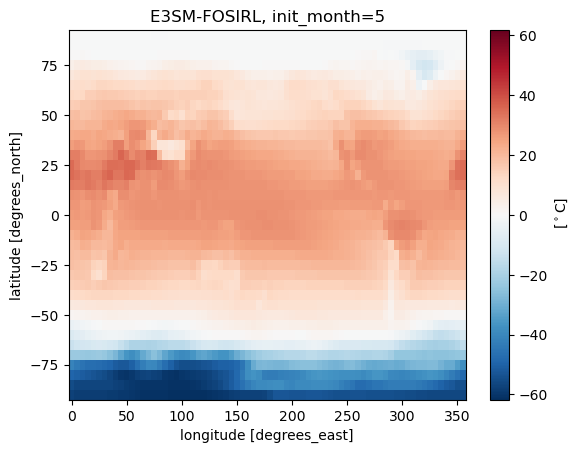

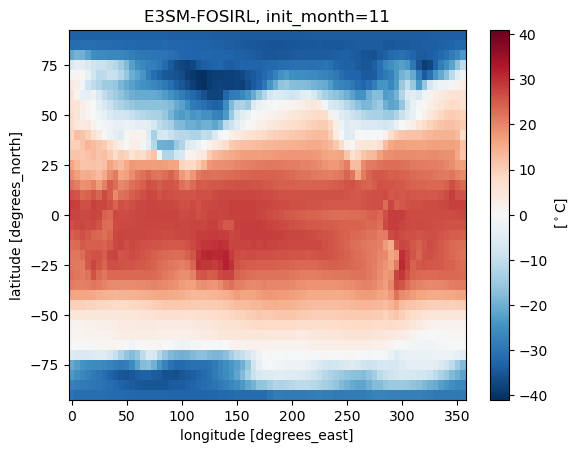

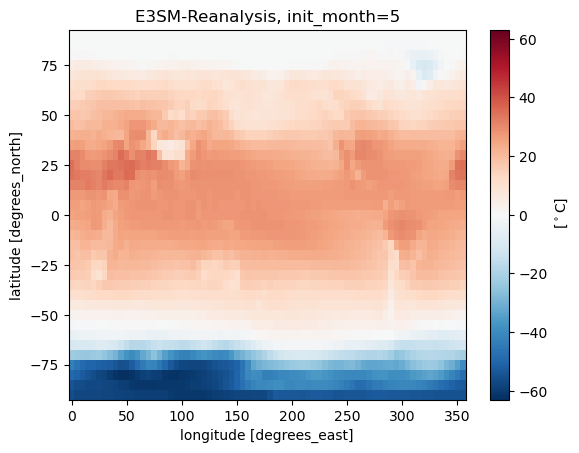

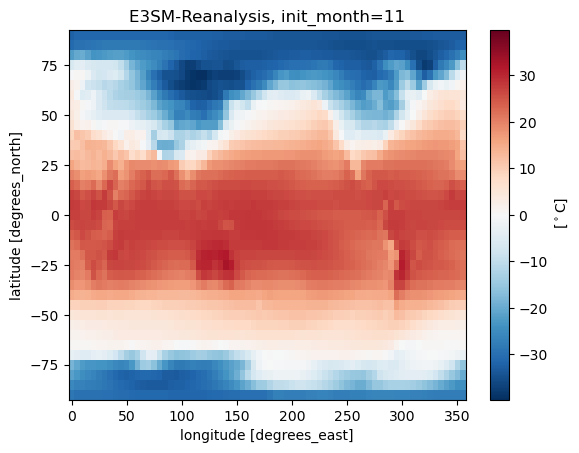

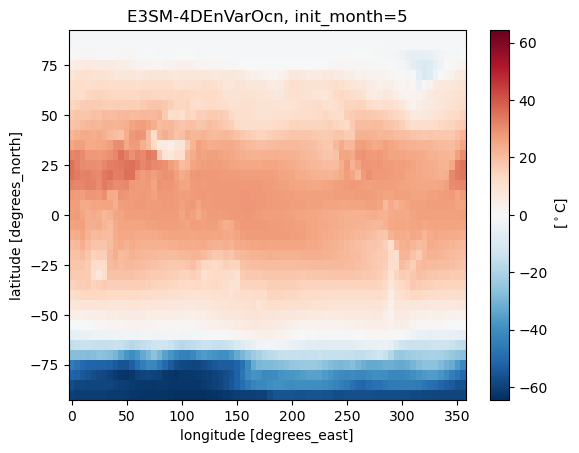

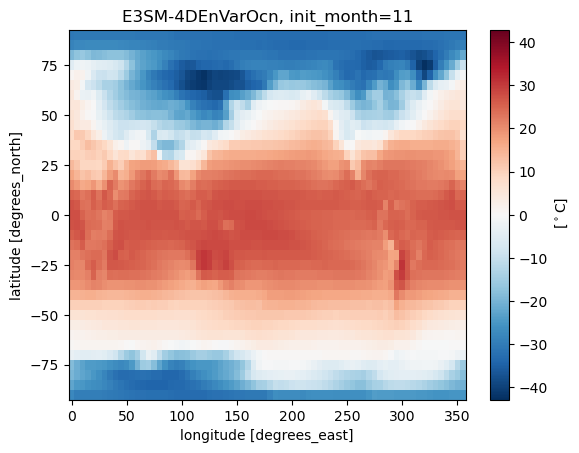

In [85]:
if use_prepared_skill_inputs:
    print('Prepared-input restart: skipping raw E3SM preview plots.')
else:
    for case_key, by_month in e3sm_da_by_case_month.items():
        for init_month, da in by_month.items():
            da.isel(Y=0, L=0, M=0).plot()
            plt.title(f"{case_key}, init_month={init_month}")
            plt.show()




### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [86]:
%%time
# Load a provenance-aware regridded observation cache. Snapshot mode never
# touches the observation archive and requires this product to exist.
obs_dir = WORKFLOW_SETTINGS['paths']['obs_data_dir']
obs_name, obs_var = cfg['obs_name'], cfg['obs_var']
obs_map = {field: obs_var}
obs_chunks = {'time': 24, 'lat': 90, 'lon': 180}
obs_cache_path = (
    S2D_DIAG_ROOT / 'observations' / 'leadtime_acc' / 'prepared_skill' /
    'atm' / field / f"{obs_name}_{obs_source_identity.split(':')[-1]}.nc"
)
obs_expected_attrs = {
    'cache_kind': 'prepared_rmse_observations_v1',
    'observation_data_identity': obs_source_identity,
    'variable': field, 'target_grid': target_grid_identity,
    'regridding_method': regrid_method,
    'unit_conversion_version': 'leadtime_rmse_units_v1',
}
obs_cache_ok, obs_cache_reason = cache_status(
    obs_cache_path, expected_attrs=obs_expected_attrs,
    required_variables=('observation',))
if prepared_mode == 'require' and not obs_cache_ok:
    raise RuntimeError(
        f'Required observation cache is unavailable: {obs_cache_path}: '
        f'{obs_cache_reason}. Run once in inventory mode with archive access.')
if not obs_cache_ok:
    obs_monthly = obs_access.get_monthly_data(
        obs_dir=obs_dir, field=field, field_map=obs_map, product=obs_name,
        start_year=cfg['obs_ys'], end_year=cfg['obs_ye'], chunks=obs_chunks,
        verbose=True)
    workflow_resources.track(obs_monthly)
    obs_seas = obs_access.mon_to_seas_obs(
        obs_monthly, var=obs_var, field_map=obs_map).chunk(obs_chunks)
    regridder_obs = regrid.make_regridder(
        obs_monthly, destgrid, method=regrid_method, periodic=regrid_periodic)
    try:
        obs_seas_rg = regridder_obs(obs_seas, output_chunks=obs_chunks)
    except TypeError:
        obs_seas_rg = regridder_obs(obs_seas)
    obs_seas_rg = cfg['obs_convert'](obs_seas_rg.chunk(obs_chunks))
    obs_cache = obs_seas_rg.rename('observation').to_dataset()
    obs_cache.attrs.update(obs_expected_attrs)
    atomic_to_netcdf(obs_cache, obs_cache_path, **seasonal_write_options)
obs_prepared = workflow_resources.track(xr.open_dataset(obs_cache_path, chunks=obs_chunks))
obs_seas_rg = obs_prepared['observation']
print(f'Prepared observations: {obs_cache_path}')
print(obs_seas_rg)


[OBS] Mapping field 'TREFHT' -> 'tas'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/tas_197901_201912.nc


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 27.37 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Prepared observations: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/observations/leadtime_acc/prepared_skill/atm/TREFHT/ERA5_e2ad5aced569f61f11bf06446e091160.nc
<xarray.DataArray 'observation' (time: 490, lat: 37, lon: 72)> Size: 5MB
dask.array<open_dataset-observation, shape=(490, 37, 72), dtype=float32, chunksize=(24, 37, 72), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
    height   float64 8B ...
Attributes:
    regrid_method:  conservative
    units:          $^\circ$C
CPU times: user 39.1 s, sys: 5.57 s, total: 44.7 s
Wall time: 1min 12s


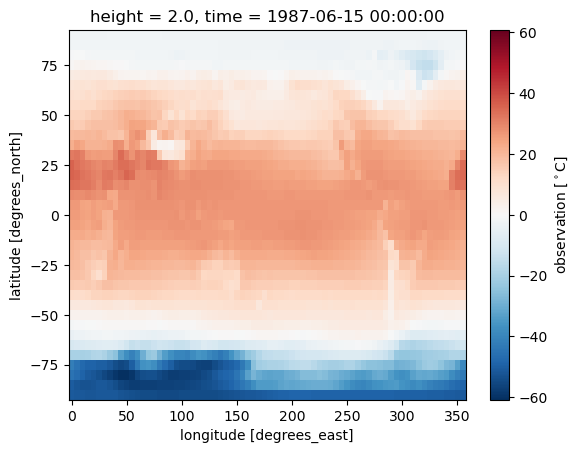

In [87]:
if source_identity_mode == 'snapshot':
    print('Snapshot restart: observation preview omitted.')
else:
    obs_seas_rg.isel(time=min(100, obs_seas_rg.sizes['time'] - 1)).plot()


# Skill Analysis

In [88]:
%%time
# Valid times are captured by the E3SM regridding cell before its seasonal
# source datasets are released.
if "time_by_case_month" not in globals():
    raise RuntimeError("Run the E3SM seasonal regridding cell first.")

# Backward-compatible convenience variables for exploratory cells.
time_by_month = time_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)


CPU times: user 7 μs, sys: 2 μs, total: 9 μs
Wall time: 14.1 μs


In [89]:
%%time
# Load or build provenance-aware de-drifted anomaly caches by case/month.

anom_by_case_month = {}
clim_by_case_month = {}
time_by_case_month = globals().get("time_by_case_month", {})

for case_key in E3SM_CASES:
    anom_by_case_month[case_key] = {}
    clim_by_case_month[case_key] = {}
    time_by_case_month.setdefault(case_key, {})

    for init_month in init_months:
        case_info = E3SM_CASES[case_key]
        prepared_path, expected = prepared_specs_by_case_month[case_key][init_month]
        compatible, reason = prepared_skill_cache_status(prepared_path, expected_attrs=expected)
        if prepared_force_recompute or prepared_mode == "rebuild" or not compatible:
            print(f"Recomputing {prepared_path}: {reason}")
            anomaly, climatology = stats.remove_drift(
                e3sm_da_by_case_month[case_key][init_month],
                time_by_case_month[case_key][init_month], climy0, climy1)
            prepared = build_prepared_skill_dataset(
                anomaly, climatology, time_by_case_month[case_key][init_month],
                source=case_info["cache_tag"], source_data_identity=expected["source_data_identity"],
                case_prefix=case_info["case_prefix"], component="atm", variable=field,
                init_month=init_month, climatology_years=(climy0, climy1),
                requested_years=INIT_YEARS_BY_MONTH[init_month],
                target_grid=expected["target_grid"], regridding_method=regrid_method,
                ensemble_member_count=case_nens, lead_count=case_nlead // 3,
                unit_conversion_version="leadtime_rmse_units_v1")
            write_prepared_skill_dataset(prepared, prepared_path)
        prepared = workflow_resources.track(open_prepared_skill_dataset(
            prepared_path, expected_attrs=expected, chunks=mchunk))
        anom_by_case_month[case_key][init_month] = prepared["anomaly"]
        clim_by_case_month[case_key][init_month] = prepared["climatology"]
        time_by_case_month[case_key][init_month] = prepared["time"].load()

# Backward-compatible convenience variables for exploratory cells.
anom_by_month = anom_by_case_month[E3SM_REFERENCE_CASE]
clim_by_month = clim_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_anom = anom_by_month.get(5)
e3smle11_anom = anom_by_month.get(11)
e3smle05_clim = clim_by_month.get(5)
e3smle11_clim = clim_by_month.get(11)

time_by_month = time_by_case_month.get(E3SM_REFERENCE_CASE, {})
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/atm/TREFHT/JRA55_FOSIRL_05_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_35fe23047634.nc: file does not exist


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/atm/TREFHT/JRA55_FOSIRL_11_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_2a4e8c4b4567.nc: file does not exist


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/atm/TREFHT/Reanalysis_05_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_a6a0c0402245.nc: file does not exist


...

/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/prepared_skill/atm/TREFHT/4DEnVarOcn_05_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_5a2f153504d4.nc: file does not exist


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/prepared_skill/atm/TREFHT/4DEnVarOcn_11_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m10_l8_086a13683d37.nc: file does not exist
CPU times: user 8.21 s, sys: 3.04 s, total: 11.3 s
Wall time: 1min 9s


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


In [90]:
%%time
# Load or build the CESM-SMYLE prepared anomaly layer.
# Cache specifications use the configured year cohort and are available offline.

smyle_anom_by_month = {}
smyle_clim_by_month = {}
smyle_time_by_month = globals().get("smyle_time_by_month", {})

for init_month in init_months:
    smyle_years = INIT_YEARS_BY_MONTH[init_month]
    prepared_path, expected = smyle_prepared_specs_by_month[init_month]
    compatible, reason = prepared_skill_cache_status(prepared_path, expected_attrs=expected)
    if prepared_force_recompute or prepared_mode == "rebuild" or not compatible:
        print(f"Recomputing {prepared_path}: {reason}")
        anomaly, climatology = stats.remove_drift(
            smyle_da_by_month[init_month], smyle_time_by_month[init_month], climy0, climy1)
        prepared = build_prepared_skill_dataset(
            anomaly, climatology, smyle_time_by_month[init_month],
            source="CESM-SMYLE", source_data_identity=expected["source_data_identity"],
            case_prefix="b.e21.BSMYLE.f09_g17", component="atm", variable=field,
            init_month=init_month, climatology_years=(climy0, climy1),
            requested_years=smyle_years, target_grid=expected["target_grid"],
            regridding_method=regrid_method, ensemble_member_count=smyle_nens,
            lead_count=case_nlead // 3, unit_conversion_version="leadtime_rmse_units_v1")
        write_prepared_skill_dataset(prepared, prepared_path)
    prepared = workflow_resources.track(open_prepared_skill_dataset(
        prepared_path, expected_attrs=expected, chunks=mchunk))
    smyle_anom_by_month[init_month] = prepared["anomaly"]
    smyle_clim_by_month[init_month] = prepared["climatology"]
    smyle_time_by_month[init_month] = prepared["time"].load()

smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)
smyle05_anom = smyle_anom_by_month.get(5)
smyle11_anom = smyle_anom_by_month.get(11)
smyle05_clim = smyle_clim_by_month.get(5)
smyle11_clim = smyle_clim_by_month.get(11)

# Memory cleanup: delete regridded SMYLE raw data
import gc
try:
    del smyle_da_by_month
    del smyle05_da
    del smyle11_da
except NameError:
    pass
gc.collect()


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/prepared_skill/atm/TREFHT/CESM_SMYLE_05_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m20_l8_44a54905cbd1.nc: file does not exist


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/prepared_skill/atm/TREFHT/CESM_SMYLE_11_TREFHT_seasonal_anomaly_y1980-2011_ny32_clim_1981_2010_m20_l8_7df674a0a895.nc: file does not exist


/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 3. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))
/global/u2/z/zhan391/code/ESP-Lab/esp_lab/leadtime_prepared_cache.py:349: UserWarning: The specified chunks separate the stored chunks along dimension "M" starting at index 2. This could degrade performance. Instead, consider rechunking after loading.
  dataset = xr.open_dataset(path, chunks=dict(chunks or {}))


CPU times: user 7.76 s, sys: 3.2 s, total: 11 s
Wall time: 1min 8s


6019

In [91]:
run_drift_check = False
if run_drift_check:
    for case_key in E3SM_CASES:
        for init_month in init_months:
            check_remove_drift_sample(
                e3sm_da_by_case_month[case_key][init_month],
                time_by_case_month[case_key][init_month],
                anom_by_case_month[case_key][init_month],
                clim_by_case_month[case_key][init_month],
                climy0, climy1, sample={'L': 0, 'lat': 0, 'lon': 0},
                name=f'{case_key}, init_month={init_month}')

# Validation is the final consumer of the regridded raw E3SM data.
import gc
try:
    del e3sm_da_by_case_month
    del e3smle_da_by_month
    del e3smle05_da
    del e3smle11_da
except NameError:
    pass
gc.collect()


135

In [92]:
%%time
# Compute and save E3SM skill data separately for each case/init month.
# Files are stored under <case>/leadtime_acc/skill/atm/<field>/.
e3smle_skill_dir = None

# False reuses existing skill NetCDF files; set True only for intentional regeneration.
force_compute = WORKFLOW_SETTINGS['cache']['force_compute_skill']
detrend = WORKFLOW_SETTINGS['skill']['detrend']

skill_chunk_model = {
    "Y": -1,
    "L": 8,
    "M": 2,
    "lat": 45,
    "lon": 90,
}

skill_chunk_obs = {
    "time": -1,
    "lat": 45,
    "lon": 90,
}

clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
clim_end = cftime.DatetimeNoLeap(climy1, 12, 31)

NETCDF_WRITE_OPTIONS = {
    'cleanup_temporary': WORKFLOW_SETTINGS['cache']['cleanup_temp_files'],
    'temp_file_max_age_hours': WORKFLOW_SETTINGS['cache']['temp_file_max_age_hours'],
}

def compact_skill_year_tag(values):
    years_this = sorted({int(str(value)[:4]) for value in values})
    if not years_this:
        raise ValueError('Skill verification-year cohort is empty.')
    return f"y{years_this[0]}-{years_this[-1]}_ny{len(years_this)}"

skill_lead_start = WORKFLOW_SETTINGS['skill']['lead_start']
skill_lead_end = WORKFLOW_SETTINGS['skill']['lead_end']

common_skill_years_by_month = {}
for init_month in init_months:
    # Retain the native Y coordinate values so .sel() works for integer,
    # string, and datetime-like initialization coordinates.
    common_years = np.intersect1d(
        smyle_anom_by_month[init_month].Y.values,
        smyle_time_by_month[init_month].Y.values,
    )
    for case in E3SM_CASES:
        common_years = np.intersect1d(
            common_years, anom_by_case_month[case][init_month].Y.values
        )
        common_years = np.intersect1d(
            common_years, time_by_case_month[case][init_month].Y.values
        )
    if len(common_years) < 3:
        raise ValueError(
            f'Need at least three common verification years for init_month={init_month}; '
            f'found {common_years}'
        )
    common_skill_years_by_month[init_month] = common_years
    print(f'Common skill years for init_month={init_month}: {common_years[0]}-'
          f'{common_years[-1]} (n={len(common_years)})')

skill_by_case_month = {}
obs_skill = obs_seas_rg.chunk(skill_chunk_obs)

for case_key, case_info in E3SM_CASES.items():
    cache_tag = case_info["cache_tag"]
    skill_dir = e3sm_leadtime_dir(case_info, "skill", field)
    skill_dir.mkdir(parents=True, exist_ok=True)
    skill_by_case_month[case_key] = {}

    for init_month in init_months:
        verification_years = common_skill_years_by_month[init_month]
        year_tag = compact_skill_year_tag(verification_years)
        trend_tag = '_detrend' if detrend else ''
        outname = (
            f"{cache_tag}{init_month:02d}_{field}_skill_{year_tag}_"
            f"clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}{trend_tag}.nc"
        )

        outfile = skill_dir / outname
        model_anom = anom_by_case_month[case_key][init_month].sel(
            Y=verification_years
        ).chunk(skill_chunk_model)
        model_time = time_by_case_month[case_key][init_month].sel(Y=verification_years)
        expected_attrs = expected_skill_cache_attrs(
            source=cache_tag, source_data_identity=e3sm_source_identity_by_case_month[case_key][init_month],
            case_prefix=case_info['case_prefix'], variable=field, init_month=init_month,
            verification_years=verification_years, climatology_years=(climy0, climy1),
            observation_product=cfg['obs_name'], observation_variable=cfg['obs_var'],
            observation_data_identity=obs_source_identity,
            target_grid=target_grid_identity, regridding_method=regrid_method,
            ensemble_member_count=model_anom.sizes['M'], lead_start=skill_lead_start, lead_end=skill_lead_end,
            detrend=detrend, unit_conversion_version='leadtime_rmse_units_v1',
            cache_kind='seasonal_normalized_rmse_skill')
        compatible, reason = cache_status(
            outfile, expected_attrs=expected_attrs, required_variables=('rmse', 'sig_obs'))

        if compatible and not force_compute:
            skill_ds = load_netcdf(outfile)
        else:
            print(f'Recomputing {outfile}: {reason}')

            skill = stats.compute_skill_seasonal(
                model_anom,
                model_time,
                obs_skill,
                clim_start,
                clim_end,
                skill_lead_start,
                skill_lead_end,
                resamp=0,
                detrend=detrend,
            )

            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            }).compute()

            skill_ds.attrs.update(expected_attrs)
            atomic_to_netcdf(skill_ds, outfile, **NETCDF_WRITE_OPTIONS)

        skill_by_case_month[case_key][init_month] = skill_ds

        print(outfile)
        print(skill_ds)

# Backward-compatible aliases.
skill_by_month = skill_by_case_month[E3SM_REFERENCE_CASE]
skill05_ds = skill_by_month.get(5)
skill11_ds = skill_by_month.get(11)




Common skill years for init_month=5: 1980050100-2011050100 (n=32)
Common skill years for init_month=11: 1980110100-2011110100 (n=32)
Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/atm/TREFHT/JRA55_FOSIRL05_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc: file does not exist


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/atm/TREFHT/JRA55_FOSIRL05_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB -0.04192 -0.03646 -0.03981 ... nan nan
    pval     (L, lat, lon) float64 170kB 0.8259 0.8483 0.8345 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 1.062 1.061 1.061 1.061 ... nan nan nan
    msss     (L, lat, lon) float32 85kB -0.1276 -0.1262 -0.1264 ... nan nan nan
    rpc      (L, lat, lon) float64 170kB nan nan nan nan nan ... nan nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.537 1.543 1.556 ... 1.703 1.726 1.75
    sig_sig  (L, lat, lon) float32 85kB 0.487

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/atm/TREFHT/JRA55_FOSIRL11_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.03312 0.01474 0.01623 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.8671 0.9395 0.9334 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 1.064 1.069 1.067 1.066 ... nan nan nan
    msss     (L, lat, lon) float32 85kB -0.133 -0.1425 -0.1393 ... nan nan nan
    rpc      (L, lat, lon) float64 170kB 0.06259 0.02773 0.03053 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.13 1.137 1.144 ... 1.933 1.935 1.937
    sig_sig  (L, lat, lon) float32 85kB 0.450

...

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/skill/atm/TREFHT/Reanalysis11_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.3284 0.2972 0.3024 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.1172 0.1584 0.1509 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 0.9464 0.9584 0.9561 ... nan nan nan
    msss     (L, lat, lon) float32 85kB 0.1043 0.08151 0.08579 ... nan nan nan
    rpc      (L, lat, lon) float64 170kB 0.6631 0.6092 0.6196 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.13 1.137 1.144 ... 1.933 1.935 1.937
    sig_sig  (L, lat, lon) float32 85kB 0.4375 0.4303 0.43

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/skill/atm/TREFHT/4DEnVarOcn05_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.1898 0.1934 0.1998 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.3064 0.2973 0.2813 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 0.991 0.9905 0.988 0.986 ... nan nan nan
    msss     (L, lat, lon) float32 85kB 0.01795 0.01887 0.02381 ... nan nan nan
    rpc      (L, lat, lon) float64 170kB 0.5094 0.5117 0.5285 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.537 1.543 1.556 ... 1.703 1.726 1.75
    sig_sig  (L, lat, lon) float32 85kB 0.4983 0.5077

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/skill/atm/TREFHT/4DEnVarOcn11_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.136 0.1386 0.1397 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.4581 0.4494 0.4457 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 1.049 1.039 1.038 1.037 ... nan nan nan
    msss     (L, lat, lon) float32 85kB -0.1012 -0.08051 -0.07754 ... nan nan
    rpc      (L, lat, lon) float64 170kB 0.2593 0.281 0.2833 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.13 1.137 1.144 ... 1.933 1.935 1.937
    sig_sig  (L, lat, lon) float32 85kB 0.5443 0.5164 0.51

In [93]:
%%time

def e3sm_case_dir(case_info):
    return E3SM_DIAG_ROOT / case_info["cache_tag"]

def e3sm_leadtime_dir(case_info, stage, *parts):
    path = e3sm_case_dir(case_info) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path

def smyle_leadtime_dir(stage, *parts):
    path = Path(CESM_SMYLE_OUTDIR) / "leadtime_acc" / str(stage) / "atm"
    for part in parts:
        path = path / str(part)
    return path

# Compute and save CESM-SMYLE benchmark skill with the same observations/settings.
smyle_skill_outdir = smyle_leadtime_dir("skill", field)
os.makedirs(smyle_skill_outdir, exist_ok=True)

smyle_skill_by_month = {}
obs_skill = obs_skill.chunk(skill_chunk_obs)

for init_month in init_months:
    verification_years = common_skill_years_by_month[init_month]
    year_tag = compact_skill_year_tag(verification_years)
    trend_tag = '_detrend' if detrend else ''
    outname = (
        f"BSMYLE{init_month:02d}_{field}_skill_{year_tag}_"
        f"clim_{climy0}_{climy1}_l{skill_lead_start}-{skill_lead_end}_overlap{trend_tag}.nc"
    )

    outfile = Path(smyle_skill_outdir) / outname
    model_anom = smyle_anom_by_month[init_month].sel(
        Y=verification_years
    ).chunk(skill_chunk_model)
    model_time = smyle_time_by_month[init_month].sel(Y=verification_years)
    expected_attrs = expected_skill_cache_attrs(
        source='CESM-SMYLE', source_data_identity=smyle_source_identity_by_month[init_month],
        case_prefix='b.e21.BSMYLE.f09_g17', variable=field, init_month=init_month,
        verification_years=verification_years, climatology_years=(climy0, climy1),
        observation_product=cfg['obs_name'], observation_variable=cfg['obs_var'],
        observation_data_identity=obs_source_identity,
        target_grid=target_grid_identity, regridding_method=regrid_method,
        ensemble_member_count=model_anom.sizes['M'], lead_start=skill_lead_start, lead_end=skill_lead_end,
        detrend=detrend, unit_conversion_version='leadtime_rmse_units_v1',
        cache_kind='seasonal_normalized_rmse_skill')
    compatible, reason = cache_status(
        outfile, expected_attrs=expected_attrs, required_variables=('rmse', 'sig_obs'))

    if compatible and not force_compute:
        skill_ds = load_netcdf(outfile)
    else:
        print(f'Recomputing {outfile}: {reason}')

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            skill_lead_start,
            skill_lead_end,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.attrs.update(expected_attrs)
        atomic_to_netcdf(skill_ds, outfile, **NETCDF_WRITE_OPTIONS)

    smyle_skill_by_month[init_month] = skill_ds
    print(outfile)
    print(skill_ds)

smyle05_skill_ds = smyle_skill_by_month.get(5)
smyle11_skill_ds = smyle_skill_by_month.get(11)

skill_delta_by_case_month = {
    case_key: {
        init_month: skill_by_case_month[case_key][init_month].corr - smyle_skill_by_month[init_month].corr
        for init_month in init_months
    }
    for case_key in E3SM_CASES
}

# Backward-compatible alias.
skill_delta_by_month = skill_delta_by_case_month[E3SM_REFERENCE_CASE]




Recomputing /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/skill/atm/TREFHT/BSMYLE05_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8_overlap.nc: file does not exist


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/skill/atm/TREFHT/BSMYLE05_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8_overlap.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.1226 0.1511 0.1577 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.5186 0.4256 0.4052 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 0.993 0.9885 0.9875 ... nan nan nan
    msss     (L, lat, lon) float32 85kB 0.01401 0.02281 0.0248 ... nan nan nan
    rpc      (L, lat, lon) float64 170kB 0.5447 0.6801 0.7087 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.537 1.543 1.556 ... 1.703 1.726 1.75
    sig_sig  (L, lat, lon) float32 85kB 0.2369 0.2316 0

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/skill/atm/TREFHT/BSMYLE11_TREFHT_skill_y1980-2011_ny32_clim_1981_2010_l1-8_overlap.nc
<xarray.Dataset> Size: 939kB
Dimensions:  (lat: 37, lon: 72, L: 8)
Coordinates:
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
    height   float64 8B 2.0
Data variables:
    corr     (L, lat, lon) float32 85kB 0.1547 0.1017 0.09766 ... nan nan nan
    pval     (L, lat, lon) float64 170kB 0.4317 0.6065 0.621 ... nan nan nan
    rmse     (L, lat, lon) float32 85kB 1.002 1.019 1.021 1.019 ... nan nan nan
    msss     (L, lat, lon) float32 85kB -0.004455 -0.03873 -0.04158 ... nan nan
    rpc      (L, lat, lon) float64 170kB 0.3517 0.2407 0.2336 ... nan nan nan
    sig_obs  (L, lat, lon) float32 85kB 1.13 1.137 1.144 ... 1.933 1.935 1.937
    sig_sig  (L, lat, lon) float32 85kB 0.3586 0.3

### Final RMSE Plot: BSMYLE vs E3SMLE
- Reads saved skill files for both BSMYLE/CESM-SMYLE and E3SMLE.
- Plots each initialization month as paired columns: CESM-SMYLE on the left, E3SMLE on the right.
- Adds light latitude-longitude gridlines with labels only on the outer plot edges.


working on figure: fig_2a_trefht_rmse_global.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_2a_trefht_rmse_global.png


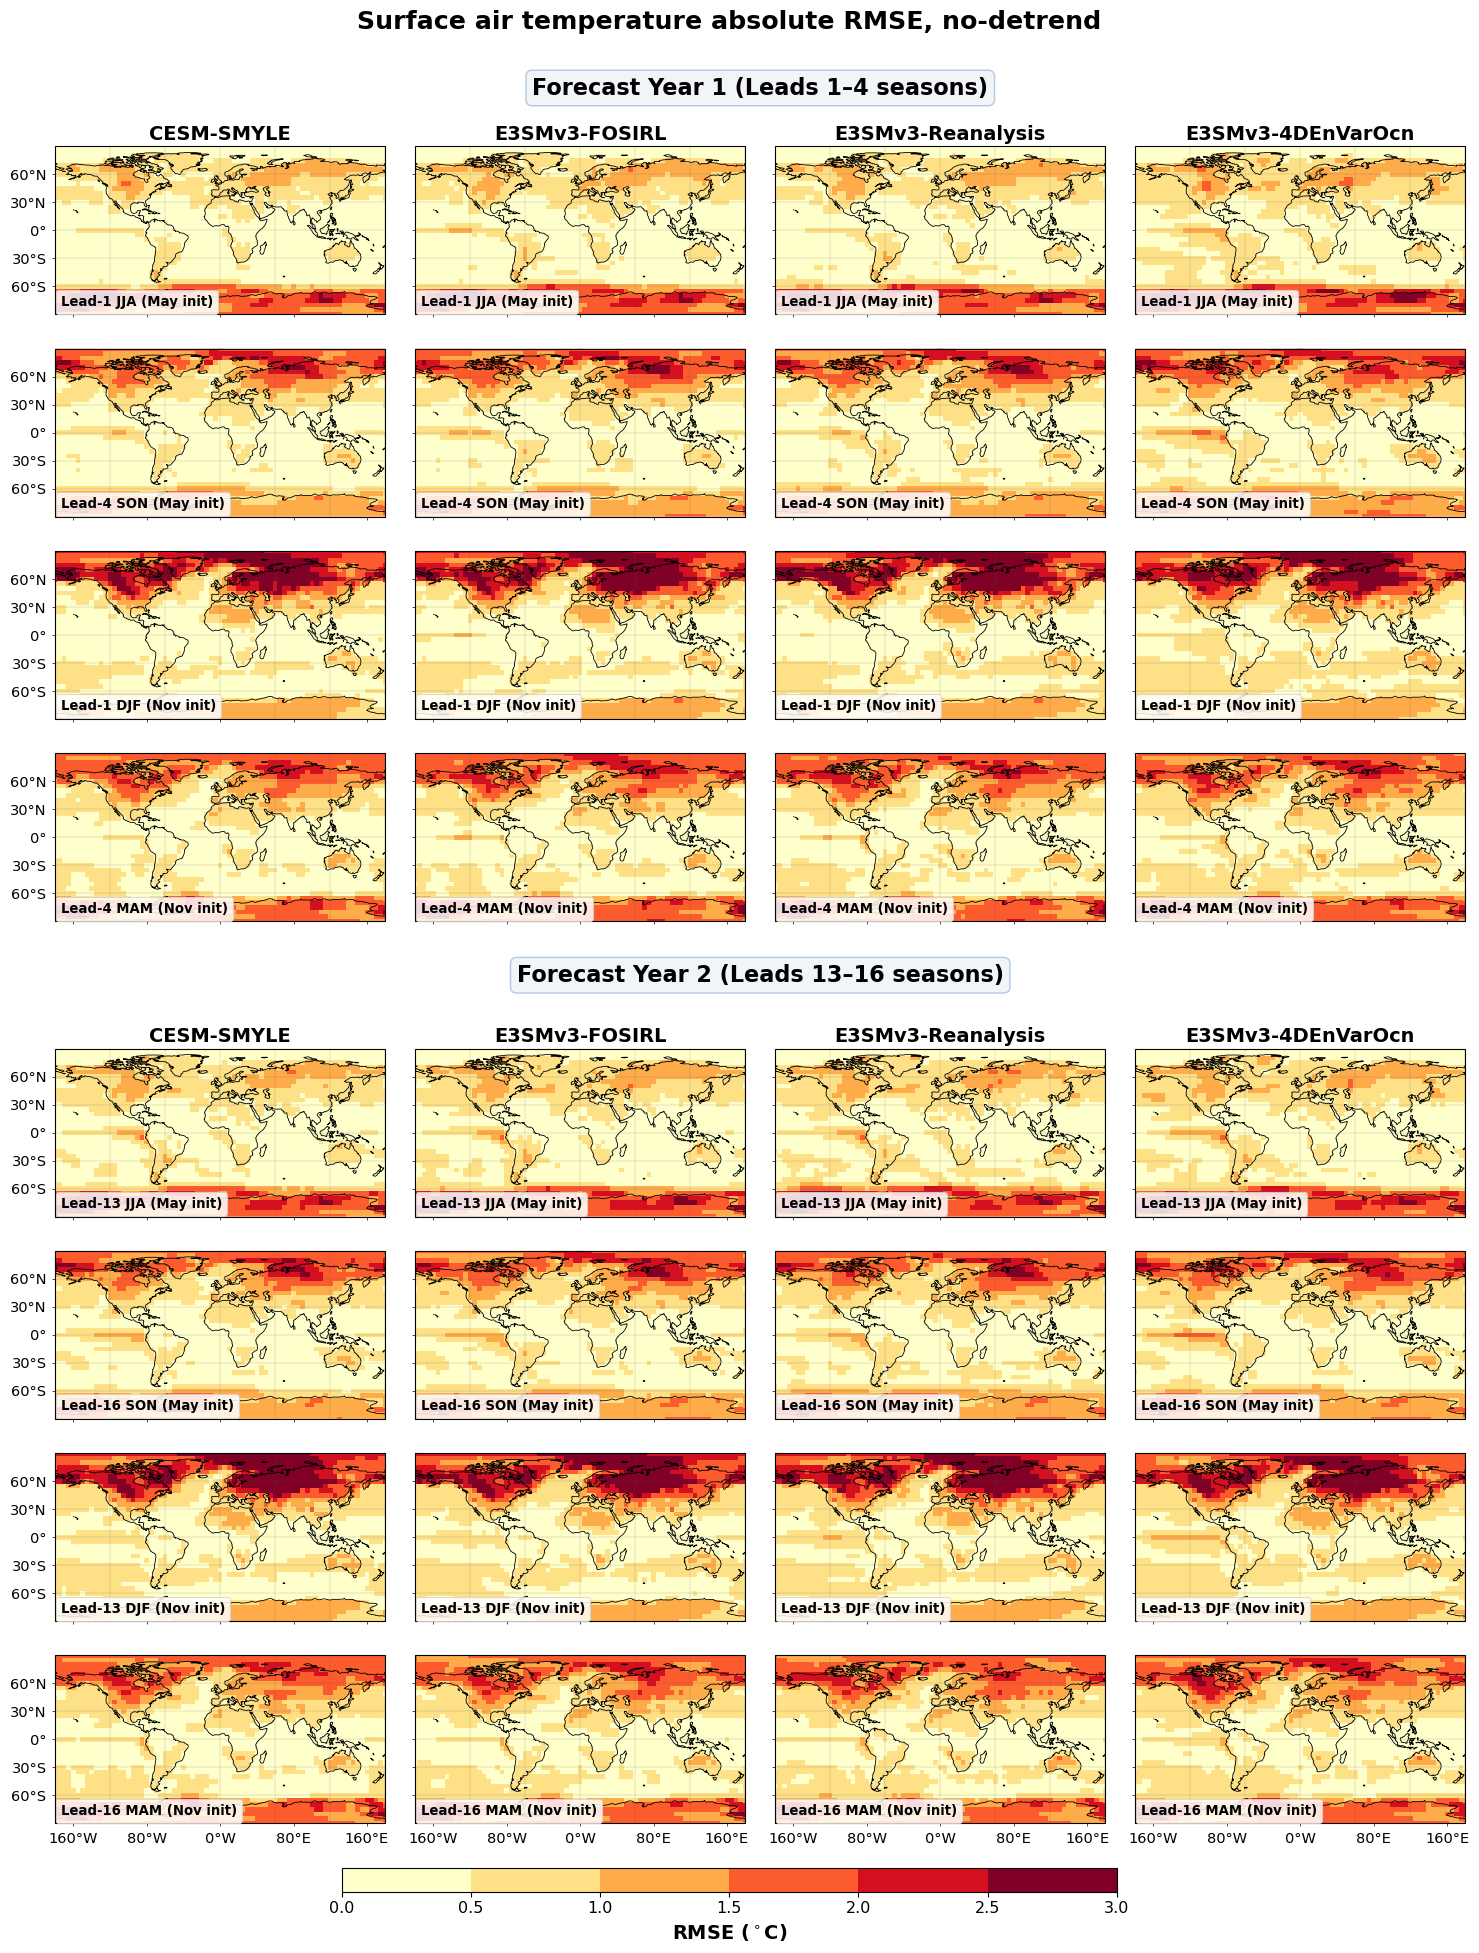

CPU times: user 8.68 s, sys: 1.35 s, total: 10 s
Wall time: 10.5 s


In [94]:
%%time
# =============================================================================
# Setup parameters: Global RMSE map layout and styling
# =============================================================================
# Typography & font sizes
fontz = 14
panel_title_size = fontz
section_title_size = fontz * 1.15
lead_badge_size = fontz - 4.5
lat_lon_label_size = fontz - 3.5
colorbar_label_size = fontz
colorbar_tick_size = fontz - 2.5
suptitle_size = fontz * 1.3
fweight = "bold"

# Figure geometry and resolution
fig_width = 15.5
fig_height = 19.5
dpi = globals().get("dpi", 300)

# GridSpec spacing and section partition
gs_top = 0.915
gs_bottom = 0.055
gs_left = 0.065
gs_right = 0.975
gs_hspace = 0.22
gs_wspace = 0.09
middle_gap_ratio = 0.35

# Map coordinate ticks and gridlines
lon_ticks = [-160, -80, 0, 80, 160]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"

# Shading colormap and cutoff
cmap = "YlOrRd"
coff = 0.5

# Colorbar placement and orientation
colorbar_axes = [0.25, 0.020, 0.5, 0.012]
colorbar_orientation = "horizontal"

# Section banners (Year 1 and Year 2)
banner_y_year1 = 0.945
banner_y_year2 = 0.490
banner_bbox = dict(boxstyle="round,pad=0.28", facecolor="#f0f4f8", edgecolor="#b0c4de", alpha=0.92, linewidth=1.0)

# Subplot badge styling (lead and verification season)
badge_loc = "lower left"
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)

# Verification season cohort configuration
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}
season_comparisons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]

# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from cartopy.util import add_cyclic_point
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText

def map_colorbar_settings(plot_type, field):
    config = MAP_COLORBAR_CONFIG[plot_type][field]
    levels = np.asarray(config["levels"], dtype=float)
    ticks = np.asarray(config["ticks"], dtype=float)
    decimals = int(config["decimals"])
    if levels.ndim != 1 or levels.size < 2:
        raise ValueError(f"Invalid colorbar levels for {plot_type}/{field}")
    steps = np.diff(levels)
    if np.any(steps <= 0) or not np.allclose(steps, steps[0]):
        raise ValueError(f"Map helper requires uniform levels for {plot_type}/{field}")
    if np.any(ticks < levels[0]) or np.any(ticks > levels[-1]):
        raise ValueError(f"Ticks outside levels for {plot_type}/{field}")
    return levels, ticks, decimals

def seasonal_label(init_month, lead):
    center_month = ((init_month + lead - 2) % 12) + 1
    return season_names[((center_month % 12) // 3)]

def lead_label(init_month, lead):
    display_lead = lead - 2
    init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
    return f"Lead-{display_lead} {seasonal_label(init_month, lead)} ({init_label} init)"

def add_lat_lon_labels(ax, is_bottom, is_left):
    for spine in ax.spines.values():
        spine.set_linewidth(map_axis_linewidth)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(
        labelsize=lat_lon_label_size,
        length=lat_lon_tick_length, width=lat_lon_tick_width,
        top=False, right=False,
        labelbottom=is_bottom,
        labelleft=is_left,
    )
    ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=gridline_width,
        color=gridline_color, alpha=gridline_alpha, linestyle=gridline_style,
        draw_labels=False,
    )

def absolute_rmse(skill_plot):
    return rmse_utils.absolute_rmse_from_skill(skill_plot, units=metric_units)

# Data access & cases
metric = "RMSE"
metric_units = cfg.get("units", "")
metric_label = f"{metric} ({metric_units})" if metric_units else metric

model_order = ["CESM-SMYLE"] + list(E3SM_CASES)
model_display_name = {"CESM-SMYLE": "CESM-SMYLE"}
model_display_name.update({
    case_key: case_info.get("display_name", case_key)
    for case_key, case_info in E3SM_CASES.items()
})

# Use the absolute-RMSE colorbar selected with `field` above.
rmse_levels, rmse_ticks, rmse_decimals = map_colorbar_settings("absolute_rmse", field)
colorbar_levels = rmse_levels
colorbar_ticks = rmse_ticks
colorbar_tick_decimals = rmse_decimals

if "skill_by_case_month" not in globals() or "smyle_skill_by_month" not in globals():
    raise RuntimeError(
        "Run the E3SM and CESM-SMYLE skill cells first; they validate provenance "
        "and load the exact common-year cache products."
    )
skill_by_model = {
    "CESM-SMYLE": smyle_skill_by_month,
    **skill_by_case_month,
}
skill_by_month = skill_by_model[E3SM_REFERENCE_CASE]
skill_plot_by_model = skill_by_model

for spec in season_comparisons:
    init_month = spec["init_month"]
    for model in model_order:
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        available = np.asarray(skill_plot_by_model[model][init_month].L.values, dtype=int)
        missing = [lead for lead in spec["year_leads"] if lead not in available]
        if missing:
            raise ValueError(
                f"Missing leads {missing} for {model}, init_month={init_month}; "
                f"available={available.tolist()}"
            )

ncols = len(model_order)
nrows_per_year = len(season_comparisons)

if detrend:
    subtitle = f"{cfg['plot_name']} absolute {metric}, linear-detrend"
else:
    subtitle = f"{cfg['plot_name']} absolute {metric}, no-detrend"

rmse_by_model = {}
for model in model_order:
    rmse_by_model[model] = {}
    for init_month in sorted({spec["init_month"] for spec in season_comparisons}):
        skill_plot = skill_plot_by_model[model][init_month]
        rmse = absolute_rmse(skill_plot)
        rmse_by_model[model][init_month] = rmse

if colorbar_levels.ndim != 1 or colorbar_levels.size < 2:
    raise ValueError("colorbar_levels must contain at least two values")
level_steps = np.diff(colorbar_levels)
if np.any(level_steps <= 0) or not np.allclose(level_steps, level_steps[0]):
    raise ValueError("colorbar_levels must be strictly increasing and uniformly spaced")
cmin = float(colorbar_levels[0])
cmax = float(colorbar_levels[-1])
ci = float(level_steps[0])

figname = FIGURE_FILENAMES["global"]
print(f"working on figure: {figname}")

# Plot figure: Year 1 in top section, Year 2 in bottom section
fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=0.985)

# 9 GridSpec rows: 4 rows for Year 1, 1 gap/banner row, 4 rows for Year 2
gs = fig.add_gridspec(
    nrows=9, ncols=ncols,
    height_ratios=[1, 1, 1, 1, middle_gap_ratio, 1, 1, 1, 1],
    top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
    hspace=gs_hspace, wspace=gs_wspace,
)

# Section banners
fig.text(0.52, banner_y_year1, "Forecast Year 1 (Leads 1–4 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)
fig.text(0.52, banner_y_year2, "Forecast Year 2 (Leads 13–16 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)

clevs = np.arange(cmin, cmax + ci, ci)
norm = BoundaryNorm(clevs, ncolors=plt.get_cmap(cmap).N, clip=True)
cntr = None

for year_idx in range(2):
    row_offset = 0 if year_idx == 0 else 5
    for r, spec in enumerate(season_comparisons):
        grid_row = row_offset + r
        init_month = spec["init_month"]
        season_str = spec["season"]
        lead = spec["year_leads"][year_idx]
        display_lead = lead - 2
        init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
        badge_text = f"Lead-{display_lead} {season_str} ({init_label} init)"

        for c, model in enumerate(model_order):
            skill_plot = skill_plot_by_model[model][init_month]
            da_plot = rmse_by_model[model][init_month].sel(L=lead)
            model_name = model_display_name.get(model, model)

            ax = fig.add_subplot(gs[grid_row, c], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            if r == 0:
                ax.set_title(model_name, fontsize=panel_title_size, fontweight=fweight, pad=5)

            dat_cyc, lon_cyc = add_cyclic_point(da_plot.values, coord=skill_plot.lon.values)
            cntr = ax.pcolormesh(lon_cyc, skill_plot.lat.values, dat_cyc, shading="nearest", cmap=cmap, norm=norm, rasterized=True)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

            is_bottom = (grid_row == 8)
            is_left = (c == 0)
            add_lat_lon_labels(ax, is_bottom, is_left)

            badge = AnchoredText(
                badge_text,
                loc=badge_loc,
                prop=dict(size=lead_badge_size, weight="bold", family="sans-serif"),
                frameon=True,
                pad=badge_pad, borderpad=badge_borderpad,
            )
            badge.patch.set(**badge_bbox)
            ax.add_artist(badge)

# Horizontal Colorbar at the bottom
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(colorbar_ticks)
tick_format = f"%.{colorbar_tick_decimals}f"
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(tick_format))
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

# Save figure
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="leadtime_rmse",
    title=f"Leadtime RMSE: {field}",
    caption="RMSE skill vs lead month, global",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

working on figure: fig_2a_trefht_rmse_conus.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_2a_trefht_rmse_conus.png


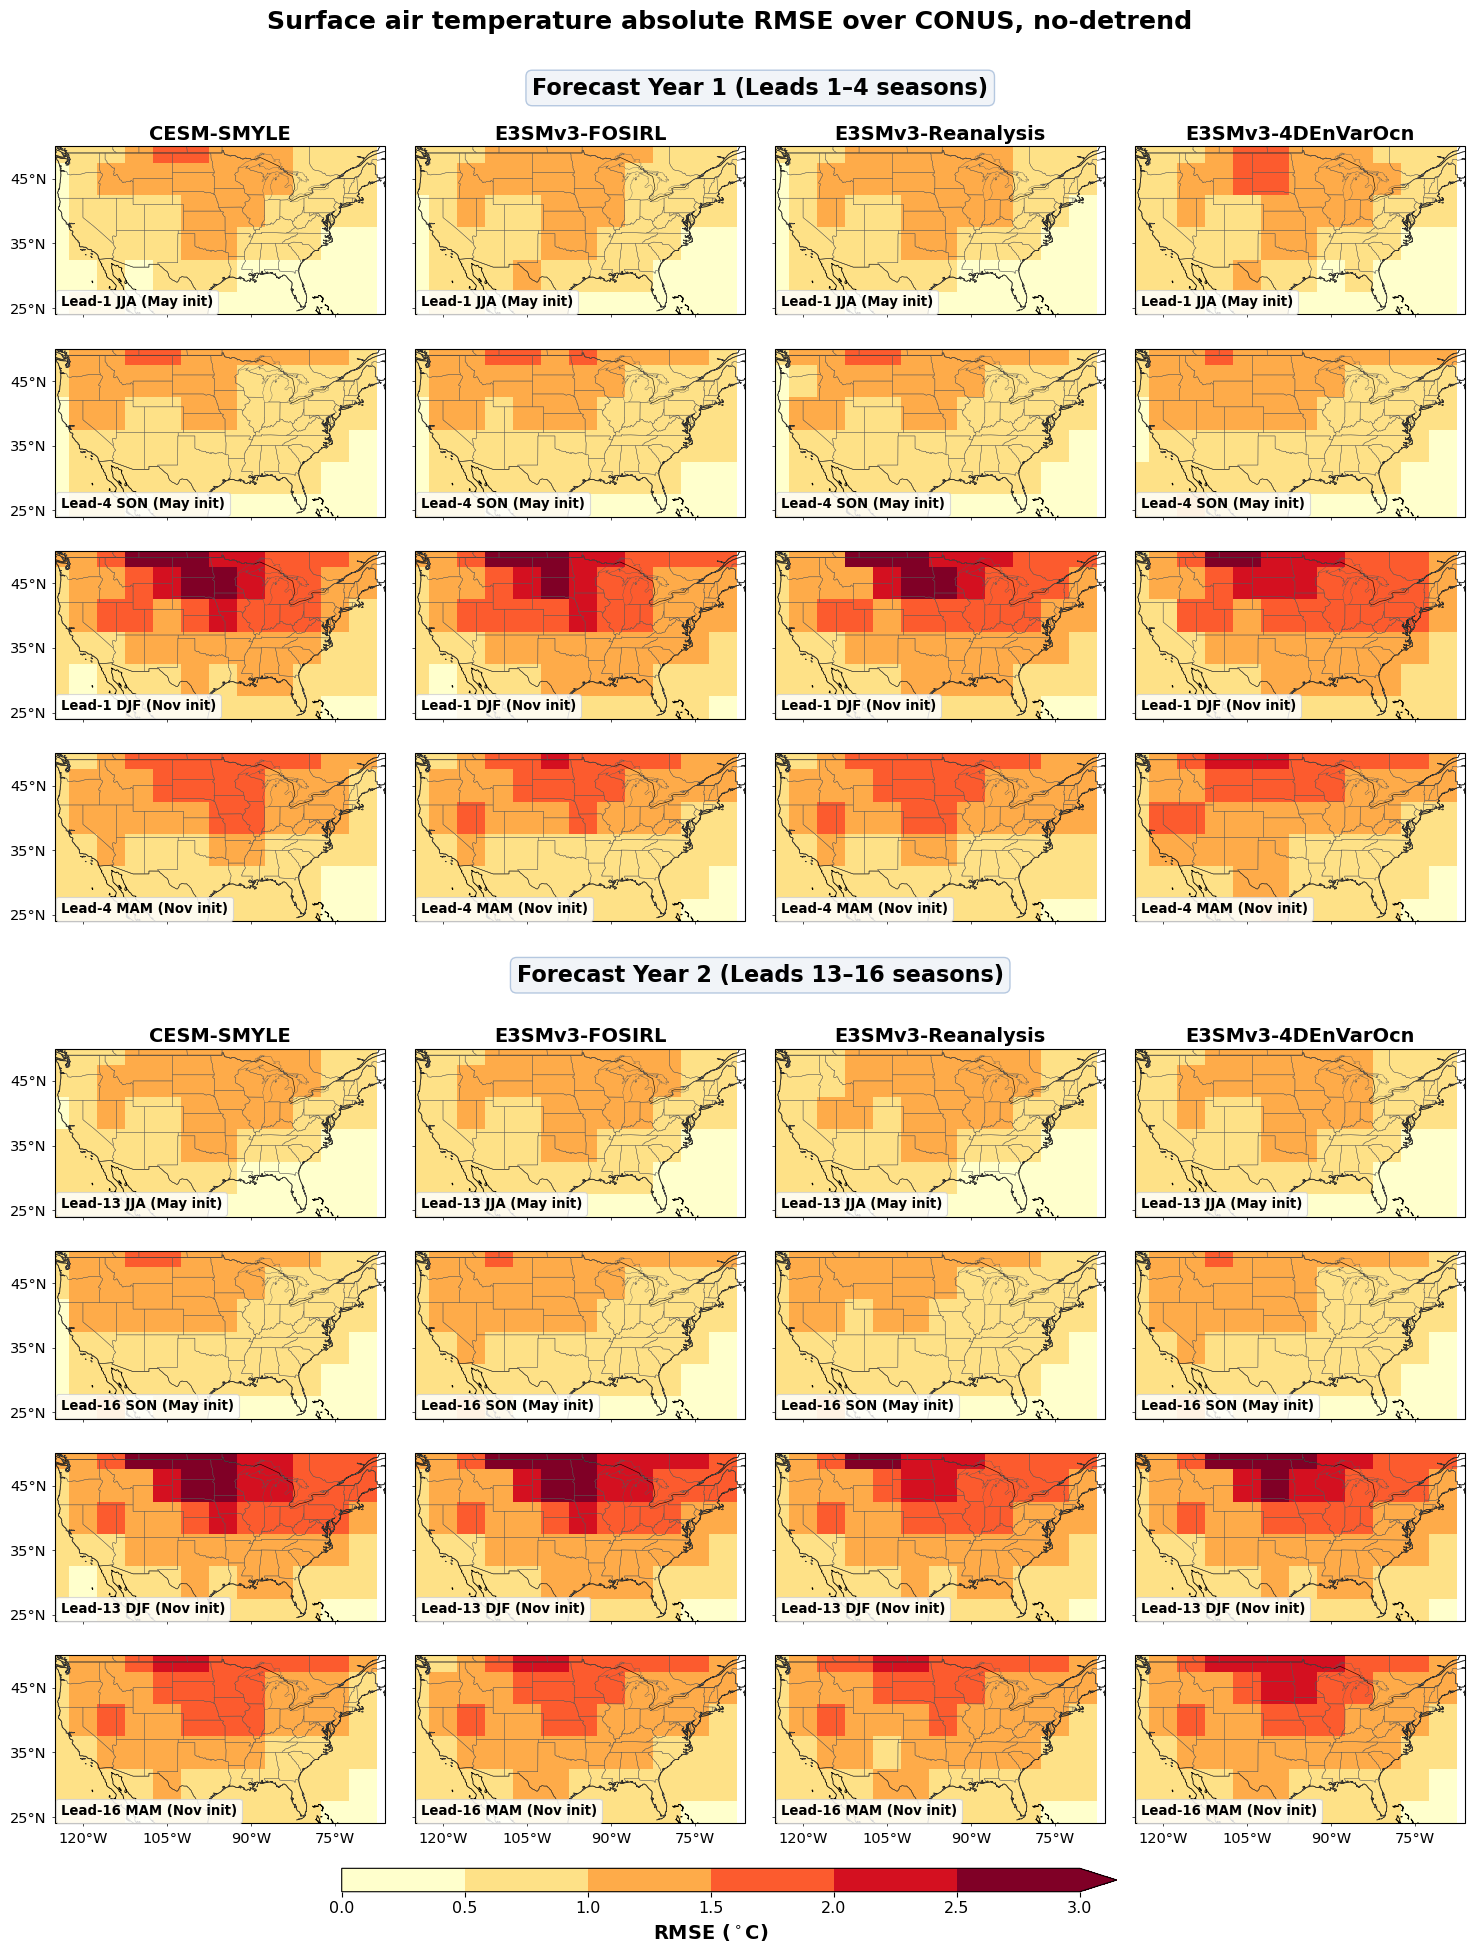

CPU times: user 5.97 s, sys: 839 ms, total: 6.81 s
Wall time: 6.39 s


In [95]:
%%time
# =============================================================================
# Setup parameters: CONUS Regional RMSE map layout and styling
# =============================================================================
# Typography & font sizes
fontz = 14
panel_title_size = fontz
section_title_size = fontz * 1.15
lead_badge_size = fontz - 4.5
lat_lon_tick_size = fontz - 3.5
colorbar_label_size = fontz
colorbar_tick_size = fontz - 2.5
suptitle_size = fontz * 1.3
fweight = "bold"

# Regional map domain and coordinate ticks
conus_extent = [-125, -66, 24, 50]
lon_ticks = [-120, -105, -90, -75]
lat_ticks = [25, 35, 45]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8

# Figure geometry and resolution
fig_width = 15.5
fig_height = 19.5
dpi = globals().get("dpi", 300)

# GridSpec spacing and section partition
gs_top = 0.915
gs_bottom = 0.055
gs_left = 0.065
gs_right = 0.975
gs_hspace = 0.22
gs_wspace = 0.09
middle_gap_ratio = 0.35

# Colorbar levels, placement and colormap
conus_cmap = "YlOrRd"
CONUS_RMSE_COLORBAR_CONFIG = {
    "TREFHT": {"levels": np.arange(0.0, 3.0 + 0.5, 0.5), "ticks": np.arange(0.0, 3.0 + 0.5, 0.5), "decimals": 1},
    "PRECT": {"levels": np.arange(0.0, 3.0 + 0.5, 0.5), "ticks": np.arange(0.0, 3.0 + 0.5, 0.5), "decimals": 1},
    "PSL": {"levels": np.arange(0.0, 3.5 + 0.5, 0.5), "ticks": np.arange(0.0, 3.5 + 0.5, 0.5), "decimals": 1},
}
conus_colorbar_config = CONUS_RMSE_COLORBAR_CONFIG.get(
    field,
    {"levels": np.arange(0.0, 3.5 + 0.5, 0.5), "ticks": np.arange(0.0, 3.5 + 0.5, 0.5), "decimals": 1}
)
conus_colorbar_levels = np.asarray(conus_colorbar_config["levels"], dtype=float)
conus_colorbar_ticks = np.asarray(conus_colorbar_config["ticks"], dtype=float)
conus_colorbar_tick_decimals = int(conus_colorbar_config["decimals"])
colorbar_axes = [0.25, 0.020, 0.5, 0.012]
colorbar_orientation = "horizontal"

# Section banners (Year 1 and Year 2)
banner_y_year1 = 0.945
banner_y_year2 = 0.490
banner_bbox = dict(boxstyle="round,pad=0.28", facecolor="#f0f4f8", edgecolor="#b0c4de", alpha=0.92, linewidth=1.0)

# Subplot badge styling (lead and verification season)
badge_loc = "lower left"
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)

# Verification season cohort configuration
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}
conus_seasons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]

# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

def require_available_lead(da, target_lead):
    available = np.asarray(da.L.values, dtype=int)
    if target_lead not in available:
        raise ValueError(
            f"Requested lead {target_lead} is unavailable; native leads are {available.tolist()}."
        )
    return int(target_lead)

def subset_conus(da):
    if float(da.lon.max()) > 180:
        da = da.sel(lon=slice(235, 294))
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
        da = da.sortby("lon")
    else:
        da = da.sel(lon=slice(conus_extent[0], conus_extent[1]))

    lat_slice = slice(conus_extent[2], conus_extent[3])
    if da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        lat_slice = slice(conus_extent[3], conus_extent[2])
    return da.sel(lat=lat_slice)

def add_conus_features(ax):
    for feature, kwargs in [
        (cfeature.COASTLINE, {"linewidth": 0.6}),
        (cfeature.BORDERS, {"linewidth": 0.4}),
        (cfeature.STATES, {"linewidth": 0.25, "edgecolor": "0.35"}),
    ]:
        try:
            ax.add_feature(feature, **kwargs)
        except Exception as err:
            print(f"Skipping Cartopy feature {feature}: {err}")

def absolute_rmse_from_skill(skill_plot):
    if "rmse" not in skill_plot:
        raise KeyError("Absolute RMSE requires rmse in the skill dataset.")
    if "sig_obs" not in skill_plot:
        raise KeyError("Absolute RMSE requires sig_obs to undo RMSE normalization.")

    rmse_abs = skill_plot.rmse * skill_plot.sig_obs
    rmse_abs.attrs["long_name"] = "RMSE"
    rmse_abs.attrs["units"] = metric_units
    return rmse_abs

if "absolute_rmse" not in globals():
    absolute_rmse = absolute_rmse_from_skill

# Cases and metadata
E3SM_CASES = globals().get("E3SM_CASES", {
    "E3SM-FOSIRL": {"cache_tag": "JRA55_FOSIRL", "display_name": "E3SMv3-FOSIRL"},
    "E3SM-Reanalysis": {"cache_tag": "Reanalysis", "display_name": "E3SMv3-Reanalysis"},
    "E3SM-4DEnVarOcn": {"cache_tag": "4DEnVarOcn", "display_name": "E3SMv3-4DEnVarOcn"},
})
conus_models = ["CESM-SMYLE"] + list(E3SM_CASES)
model_display_name = globals().get("model_display_name", {
    "CESM-SMYLE": "CESM-SMYLE",
    **{case_key: case_info.get("display_name", case_key) for case_key, case_info in E3SM_CASES.items()},
})

metric = globals().get("metric", "RMSE")
metric_units = globals().get("metric_units", cfg.get("units", ""))
metric_label = globals().get("metric_label", f"{metric} ({metric_units})" if metric_units else metric)

if "skill_plot_by_model" not in globals():
    raise RuntimeError(
        "Run the global RMSE plotting cell first so the validated common-year "
        "skill products are available."
    )

conus_fields = {model: {} for model in conus_models}
conus_actual_leads = {model: {} for model in conus_models}
for model in conus_models:
    for spec in conus_seasons:
        season_name = spec["season"]
        init_month = spec["init_month"]
        if init_month not in skill_plot_by_model[model]:
            raise KeyError(f"Missing {model} skill data for init_month={init_month}.")
        rmse_abs = absolute_rmse(skill_plot_by_model[model][init_month])
        conus_fields[model][season_name] = {}
        conus_actual_leads[model][season_name] = {}
        for target_lead in spec["year_leads"]:
            actual_lead = require_available_lead(rmse_abs, target_lead)
            conus_actual_leads[model][season_name][target_lead] = actual_lead
            conus_fields[model][season_name][target_lead] = subset_conus(
                rmse_abs.sel(L=actual_lead)
            )

conus_cmap_obj = plt.get_cmap(conus_cmap)
conus_norm = BoundaryNorm(conus_colorbar_levels, conus_cmap_obj.N, clip=False)

detrend_label = "linear-detrend" if detrend else "no-detrend"
conus_subtitle = f"{cfg['plot_name']} absolute {metric} over CONUS, {detrend_label}"

ncols = len(conus_models)
figname = FIGURE_FILENAMES["conus"]
print(f"working on figure: {figname}")

# Plot figure: Year 1 in top section, Year 2 in bottom section
fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(conus_subtitle, fontsize=suptitle_size, fontweight=fweight, y=0.985)

gs = fig.add_gridspec(
    nrows=9, ncols=ncols,
    height_ratios=[1, 1, 1, 1, middle_gap_ratio, 1, 1, 1, 1],
    top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
    hspace=gs_hspace, wspace=gs_wspace,
)

# Section banners
fig.text(0.52, banner_y_year1, "Forecast Year 1 (Leads 1–4 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)
fig.text(0.52, banner_y_year2, "Forecast Year 2 (Leads 13–16 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)

cntr = None
for year_idx in range(2):
    row_offset = 0 if year_idx == 0 else 5
    for r, spec in enumerate(conus_seasons):
        grid_row = row_offset + r
        season_str = spec["season"]
        init_month = spec["init_month"]
        target_lead = spec["year_leads"][year_idx]
        init_label = init_month_names.get(init_month, f"{init_month:02d}").title()

        for c, model in enumerate(conus_models):
            da = conus_fields[model][season_str][target_lead]
            actual_lead = conus_actual_leads[model][season_str][target_lead]
            display_lead = actual_lead - 2
            badge_text = f"Lead-{display_lead} {season_str} ({init_label} init)"
            model_name = model_display_name.get(model, model)

            ax = fig.add_subplot(gs[grid_row, c], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            if r == 0:
                ax.set_title(model_name, fontsize=panel_title_size, fontweight=fweight, pad=5)

            cntr = ax.pcolormesh(
                da.lon,
                da.lat,
                da,
                shading="nearest",
                cmap=conus_cmap_obj,
                norm=conus_norm,
                rasterized=True,
                transform=ccrs.PlateCarree(),
            )
            ax.set_extent(conus_extent, crs=ccrs.PlateCarree())
            add_conus_features(ax)

            is_bottom = (grid_row == 8)
            is_left = (c == 0)
            ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
            ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(
                labelsize=lat_lon_tick_size,
                length=lat_lon_tick_length,
                width=lat_lon_tick_width,
                labelbottom=is_bottom,
                labelleft=is_left,
                top=False, right=False,
            )

            badge = AnchoredText(
                badge_text,
                loc=badge_loc,
                prop=dict(size=lead_badge_size, weight="bold", family="sans-serif"),
                frameon=True,
                pad=badge_pad, borderpad=badge_borderpad,
            )
            badge.patch.set(**badge_bbox)
            ax.add_artist(badge)

# Horizontal Colorbar at the bottom
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation, extend="max")
cbar.set_ticks(conus_colorbar_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{conus_colorbar_tick_decimals}f")
)
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="leadtime_rmse",
    title=f"CONUS lead-time RMSE: {field}",
    caption="Absolute RMSE over CONUS by model, initialization, and forecast year",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

In [96]:
%%time
# CESM-SMYLE vs each E3SM hindcast normalized-RMSE ensemble comparison.
#
# Scientific purpose:
# 1. Restrict CESM-SMYLE and each E3SM hindcast to common verification years.
# 2. Resample the larger CESM-SMYLE ensemble to the E3SM ensemble size.
# 3. Repeat the CESM-SMYLE subsampling N times without replacement.
# 4. Compute P(E3SM nRMSE < matched-size CESM-SMYLE nRMSE).
# 5. Store two-sided resampling values and left/right robustness masks using
#    compare_alpha, matching the finite-ensemble output convention in 3_ref*.

import importlib
def _compare_dir_e3sm(case_key, category):
    path = e3sm_leadtime_dir(E3SM_CASES[case_key], "comparison", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _compare_dir_smyle(category):
    path = smyle_leadtime_dir("comparison", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _compare_resampling_cache_dir_smyle(category):
    path = smyle_leadtime_dir("resampling_cache", category, field)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


def _safe_to_netcdf(ds, path):
    """
    Safely write a Dataset to NetCDF using a temporary file first.
    This avoids corrupted cache files if the job is interrupted.
    """
    return atomic_to_netcdf(ds, path, **NETCDF_WRITE_OPTIONS)


def _open_dataset_load(path):
    """
    Open a small cached result and load it into memory.
    Used for final skill / p-value outputs, not large anomaly inputs.
    """
    with xr.open_dataset(path) as ds:
        return ds.load()


def _cache_compare_anomaly(
    da,
    path,
    varname="anom",
    chunks=None,
    force=False,
):
    """
    Save a comparison anomaly DataArray once and reopen it with Dask chunks.

    This reduces the Dask graph size because the expensive significance
    calculation starts from NetCDF reads rather than from the full upstream
    lazy-processing graph.
    """
    if force or not os.path.exists(path):
        print(f"Writing cached anomaly: {path}")
        _safe_to_netcdf(da.to_dataset(name=varname), path)

    print(f"Opening cached anomaly with Dask chunks: {path}")
    return xr.open_dataset(path, chunks=chunks)[varname]


def _case_cache_tag(case_key):
    return E3SM_CASES[case_key].get("cache_tag", case_key.replace("E3SM-", ""))


def _compare_cache_paths(case_key, init_month, ens_size, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    mode = f"{compare_mode}_n{ens_size}_iter{compare_iterations}_seed{compare_random_seed}_{year_token}"
    case_tag = _case_cache_tag(case_key)

    smyle_file = os.path.join(
        _compare_dir_smyle("resampled_rmse"),
        f"BSMYLE{init_month:02d}_{base}_resamp_to_{case_tag}_rmse_{trend}_{mode}.nc",
    )

    e3sm_file = os.path.join(
        _compare_dir_e3sm(case_key, "fixed_rmse"),
        f"{case_tag}{init_month:02d}_{base}_fixed_rmse_{trend}_{year_token}.nc",
    )

    fraction_file = os.path.join(
        _compare_dir_e3sm(case_key, "fraction_lt_smyle_rmse"),
        f"BSMYLE_lt_{case_tag}{init_month:02d}_{base}_rmse_fraction_{trend}_{mode}.nc",
    )

    return smyle_file, e3sm_file, fraction_file


def _compare_anomaly_cache_paths(case_key, init_month, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    case_tag = _case_cache_tag(case_key)

    smyle_anom_file = os.path.join(
        _compare_dir_smyle("anomalies"),
        f"BSMYLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    e3sm_anom_file = os.path.join(
        _compare_dir_e3sm(case_key, "anomalies"),
        f"{case_tag}{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    return smyle_anom_file, e3sm_anom_file


def _compare_resampling_cache_path(smyle_file, suffix_token):
    basename = os.path.basename(smyle_file)
    stem, suffix = os.path.splitext(basename)
    return os.path.join(_compare_resampling_cache_dir_smyle("resampled_rmse"), f"{stem}_{suffix_token}{suffix}")


def _compare_prepared_cache_paths(smyle_file, lead):
    return (
        _compare_resampling_cache_path(smyle_file, f"prepared_model_L{int(lead):02d}"),
        _compare_resampling_cache_path(smyle_file, f"prepared_obs_L{int(lead):02d}"),
    )


def _compare_lead_cache_path(smyle_file, lead):
    return _compare_resampling_cache_path(smyle_file, f"L{int(lead):02d}_all_iterations")


def _compare_batch_cache_path(smyle_file, lead, batch_start, batch_stop):
    return _compare_resampling_cache_path(
        smyle_file,
        f"L{int(lead):02d}_batch_{batch_start:03d}_{batch_stop:03d}",
    )


def _build_rmse_significance_dataset(
    smyle_better_fraction,
    alpha,
    left_model,
    prob_left_lower=None,
    n_iterations=None,
    matched_ensemble_size=None,
    smyle_ensemble_size=None,
):
    """Build deterministic finite-ensemble RMSE significance fields."""
    if prob_left_lower is None:
        prob_left_lower = (1.0 - smyle_better_fraction).clip(0.0, 1.0)
    ds = rmse_utils.build_rmse_significance_dataset(
        prob_left_lower, alpha=alpha, left_model=left_model, right_model='CESM-SMYLE',
        n_iterations=n_iterations, matched_ensemble_size=matched_ensemble_size)
    ds['smyle_better_fraction'] = smyle_better_fraction.astype('float32')
    if smyle_ensemble_size is not None:
        ds.attrs["smyle_ensemble_size"] = int(smyle_ensemble_size)
    return ds


def _finite_rmse_comparison_fraction(left_rmse, right_rmse):
    """Return P(left RMSE < right RMSE) over finite paired iterations."""
    return rmse_utils.rmse_comparison_fraction(left_rmse, right_rmse)

stats = importlib.reload(stats)

compare_mode = WORKFLOW_SETTINGS['significance']['mode']

compare_force_recompute = WORKFLOW_SETTINGS['cache']['force_compute_comparison']
compare_detrend = WORKFLOW_SETTINGS['skill']['detrend']
compare_random_seed = WORKFLOW_SETTINGS['significance']['random_seed']
compare_alpha = WORKFLOW_SETTINGS['significance']['alpha']

# Recommended for production:
# True  -> write comparison anomalies once and reopen as Dask-backed arrays.
# False -> directly use upstream lazy anomaly arrays.
cache_compare_anomalies = True

# Usually keep False. Persisting full anomaly arrays can increase memory pressure.
persist_compare_inputs = False

E3SM_COMPARE_CASES = [
    case_key for case_key in ["E3SM-FOSIRL", "E3SM-Reanalysis", "E3SM-4DEnVarOcn"]
    if case_key in E3SM_CASES
]

if compare_mode == "test":
    compare_init_months = [m for m in [11] if m in init_months]
    compare_iterations = WORKFLOW_SETTINGS['significance']['iterations']
    compare_lead_start = 1
    compare_lead_end = 8

elif compare_mode == "final":
    compare_init_months = [m for m in [5, 11] if m in init_months]
    compare_iterations = WORKFLOW_SETTINGS['significance']['iterations']
    compare_lead_start = 1
    compare_lead_end = 8

else:
    raise ValueError("compare_mode must be 'test' or 'final'")

if not compare_init_months:
    raise ValueError("No requested compare_init_months are available in init_months.")

# Dedicated chunks keep each lead and spatial tile manageable.
compare_chunk_model = {
    "Y": -1,
    "M": -1,
    "L": 1,
    "lat": 30,
    "lon": 60,
}
compare_chunk_obs = {
    "time": -1,
    "lat": 30,
    "lon": 60,
}
# Moderate checkpoints reduce repeated source reads while limiting worker
# memory. Completed batches are reused after an interruption or restart.
compare_iteration_batch_size = WORKFLOW_SETTINGS['significance']['iteration_batch_size']

obs_compare = obs_seas_rg.chunk(compare_chunk_obs)

smyle_compare_skill_by_case_month = {}
e3sm_compare_skill_by_case_month = {}
smyle_better_fraction_by_case_month = {}
rmse_significance_by_case_month = {}
compare_years_by_case_month = {}
compare_ens_size_by_case_month = {}

for case_key in E3SM_COMPARE_CASES:
    smyle_compare_skill_by_case_month[case_key] = {}
    e3sm_compare_skill_by_case_month[case_key] = {}
    smyle_better_fraction_by_case_month[case_key] = {}
    rmse_significance_by_case_month[case_key] = {}
    compare_years_by_case_month[case_key] = {}
    compare_ens_size_by_case_month[case_key] = {}

    for compare_init_month in compare_init_months:
        e3sm_compare_member_count = anom_by_case_month[case_key][compare_init_month].sizes["M"]
        smyle_compare_member_count = smyle_anom_by_month[compare_init_month].sizes["M"]

        if smyle_compare_member_count < e3sm_compare_member_count:
            raise ValueError(
                "This comparison expects CESM-SMYLE to be the larger ensemble; "
                f"got SMYLE={smyle_compare_member_count}, {case_key}={e3sm_compare_member_count}."
            )
        compare_ens_size = e3sm_compare_member_count
        compare_ens_size_by_case_month[case_key][compare_init_month] = compare_ens_size

        compare_years = np.intersect1d(
            smyle_anom_by_month[compare_init_month].Y.values,
            anom_by_case_month[case_key][compare_init_month].Y.values,
        )
        compare_years_by_case_month[case_key][compare_init_month] = compare_years

        smyle_file, e3sm_file, fraction_file = _compare_cache_paths(
            case_key, compare_init_month, compare_ens_size, compare_years
        )
        selection_identity = {
            'field': field, 'case': case_key, 'init_month': compare_init_month,
            'verification_years': [int(str(value)[:4]) for value in compare_years],
            'sample_size': compare_ens_size, 'iterations': compare_iterations,
            'e3sm_source_identity': e3sm_source_identity_by_case_month[case_key][compare_init_month],
            'smyle_source_identity': smyle_source_identity_by_month[compare_init_month],
            'observation_data_identity': obs_source_identity,
        }
        derived_seed = stable_resampling_seed(compare_random_seed, selection_identity)
        generated_indices = generate_member_indices(
            population_size=smyle_compare_member_count, sample_size=compare_ens_size,
            iterations=compare_iterations, seed=derived_seed)
        selection_attrs = member_selection_attrs(
            base_seed=compare_random_seed, derived_seed=derived_seed,
            identity=selection_identity, member_indices=generated_indices)
        member_indices_all = load_or_write_member_selection(
            _compare_resampling_cache_path(smyle_file, 'member_indices'), generated_indices,
            selection_attrs, smyle_compare_member_count, force=compare_force_recompute)

        if (
            not compare_force_recompute
            and os.path.exists(smyle_file)
            and os.path.exists(e3sm_file)
            and os.path.exists(fraction_file)
        ):
            print(f"Loading cached significance results for {case_key}, init_month={compare_init_month}")

            smyle_skill_tmp = _open_dataset_load(smyle_file)
            e3sm_skill_tmp = _open_dataset_load(e3sm_file)

            with xr.open_dataset(fraction_file) as ds:
                required_significance_vars = {
                    "prob_left_lower_rmse",
                    "p_two_sided_resampling",
                    "left_better",
                    "right_better",
                }
                cache_needs_upgrade = (
                    not required_significance_vars.issubset(ds.data_vars)
                    or float(ds.attrs.get("alpha", -1.0)) != float(compare_alpha)
                    or ds.attrs.get("left_model") != case_key
                    or ds.attrs.get('member_selection_checksum') != selection_attrs['member_selection_checksum']
                )
                if "smyle_better_fraction" in ds:
                    smyle_better_fraction_tmp = ds["smyle_better_fraction"].load()
                else:
                    smyle_better_fraction_tmp = (
                        1.0 - ds["prob_left_lower_rmse"]
                    ).load()
                prob_left_lower_tmp = (
                    ds["prob_left_lower_rmse"].load()
                    if "prob_left_lower_rmse" in ds else None
                )
            valid_comparison = (
                smyle_skill_tmp.rmse.notnull()
                & e3sm_skill_tmp.rmse.notnull()
            ).any("iteration")
            invalid_cached = smyle_better_fraction_tmp.notnull() & ~valid_comparison
            smyle_better_fraction_tmp = smyle_better_fraction_tmp.where(valid_comparison)
            if prob_left_lower_tmp is not None:
                invalid_cached = invalid_cached | (
                    prob_left_lower_tmp.notnull() & ~valid_comparison
                )
                prob_left_lower_tmp = prob_left_lower_tmp.where(valid_comparison)
            cache_needs_upgrade = cache_needs_upgrade or bool(invalid_cached.any())
            rmse_significance_tmp = _build_rmse_significance_dataset(
                smyle_better_fraction_tmp,
                compare_alpha,
                case_key,
                prob_left_lower=prob_left_lower_tmp,
                n_iterations=compare_iterations,
                matched_ensemble_size=compare_ens_size,
                smyle_ensemble_size=smyle_compare_member_count,
            )
            rmse_significance_tmp.attrs['member_selection_checksum'] = selection_attrs['member_selection_checksum']
            if cache_needs_upgrade:
                print("Upgrading finite-ensemble significance cache:", fraction_file)
                _safe_to_netcdf(rmse_significance_tmp, fraction_file)

        else:
            print(f"Computing significance results for {case_key}, init_month={compare_init_month}")
            print(f"compare_mode       : {compare_mode}")
            print(f"compare_iterations : {compare_iterations}")
            print(f"compare_alpha      : {compare_alpha}")
            print(f"compare_leads      : {compare_lead_start} to {compare_lead_end}")
            print(f"compare_detrend    : {compare_detrend}")
            print(f"cache anomalies    : {cache_compare_anomalies}")
            print(f"persist inputs     : {persist_compare_inputs}")

            smyle_compare_anom = (
                smyle_anom_by_month[compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            e3sm_compare_anom = (
                anom_by_case_month[case_key][compare_init_month]
                .sel(Y=compare_years)
                .chunk(compare_chunk_model)
            )

            if cache_compare_anomalies:
                smyle_anom_file, e3sm_anom_file = _compare_anomaly_cache_paths(
                    case_key, compare_init_month, compare_years
                )

                smyle_compare_anom = _cache_compare_anomaly(
                    smyle_compare_anom,
                    smyle_anom_file,
                    varname="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                )

                e3sm_compare_anom = _cache_compare_anomaly(
                    e3sm_compare_anom,
                    e3sm_anom_file,
                    varname="anom",
                    chunks=compare_chunk_model,
                    force=compare_force_recompute,
                )

            elif persist_compare_inputs:
                smyle_compare_anom = smyle_compare_anom.persist()
                e3sm_compare_anom = e3sm_compare_anom.persist()
                wait([smyle_compare_anom, e3sm_compare_anom])

            smyle_compare_time = smyle_time_by_month[compare_init_month].sel(
                Y=compare_years
            )

            e3sm_compare_time = time_by_case_month[case_key][compare_init_month].sel(
                Y=compare_years
            )

            if os.path.exists(e3sm_file) and not compare_force_recompute:
                print(f"Loading cached fixed {case_key} comparison RMSE...")
                e3sm_skill_tmp = _open_dataset_load(e3sm_file)
            else:
                print(f"Computing fixed {case_key} comparison RMSE...")
                e3sm_skill_tmp = stats.compute_skill_seasonal(
                    e3sm_compare_anom,
                    e3sm_compare_time,
                    obs_compare,
                    str(climy0),
                    str(climy1),
                    compare_lead_start,
                    compare_lead_end,
                    resamp=0,
                    detrend=compare_detrend,
                )[["rmse"]].load()
                _safe_to_netcdf(e3sm_skill_tmp, e3sm_file)

            print("Computing CESM-SMYLE matched-ensemble RMSE distribution...")

            smyle_skill_leads = []
            lead_indices = range(compare_lead_start - 1, compare_lead_end)
            prepared_chunks_model = {"time": -1, "M": -1, "lat": 30, "lon": 60}
            prepared_chunks_obs = {"time": -1, "lat": 30, "lon": 60}

            for lead_index in lead_indices:
                lead = int(smyle_compare_anom.L.values[lead_index])
                lead_file = _compare_lead_cache_path(smyle_file, lead)

                if os.path.exists(lead_file) and not compare_force_recompute:
                    print(f"  L={lead}: loading cached iterations")
                    smyle_skill_leads.append(_open_dataset_load(lead_file))
                    continue

                model_prepared_file, obs_prepared_file = _compare_prepared_cache_paths(
                    smyle_file, lead
                )

                prepared_exist = (
                    os.path.exists(model_prepared_file)
                    and os.path.exists(obs_prepared_file)
                    and not compare_force_recompute
                )
                if not prepared_exist:
                    print(f"  preparing and detrending lead L={lead}")
                    model_prepared, obs_prepared = stats.prepare_skill_seasonal_lead(
                        smyle_compare_anom,
                        smyle_compare_time,
                        obs_compare,
                        lead_index=lead_index,
                        climy0=str(climy0),
                        climy1=str(climy1),
                        detrend=compare_detrend,
                        is_anomaly=False,
                    )
                    _safe_to_netcdf(
                        model_prepared.to_dataset(name="model"), model_prepared_file
                    )
                    _safe_to_netcdf(
                        obs_prepared.to_dataset(name="obs"), obs_prepared_file
                    )

                model_prepared = xr.open_dataset(
                    model_prepared_file, chunks=prepared_chunks_model
                )["model"]
                obs_prepared = xr.open_dataset(
                    obs_prepared_file, chunks=prepared_chunks_obs
                )["obs"]

                lead_batches = []
                for batch_start in range(
                    0, compare_iterations, compare_iteration_batch_size
                ):
                    batch_stop = min(
                        batch_start + compare_iteration_batch_size, compare_iterations
                    )
                    batch_file = _compare_batch_cache_path(
                        smyle_file, lead, batch_start, batch_stop
                    )
                    if os.path.exists(batch_file) and not compare_force_recompute:
                        print(
                            f"  L={lead}: loading iterations "
                            f"{batch_start + 1}-{batch_stop}"
                        )
                        batch_skill = _open_dataset_load(batch_file)
                    else:
                        print(
                            f"  L={lead}: computing iterations "
                            f"{batch_start + 1}-{batch_stop}"
                        )
                        batch_rmse = stats.compute_resampled_nrmse_prepared(
                            model_prepared,
                            obs_prepared,
                            member_indices_all[batch_start:batch_stop],
                        ).load()
                        batch_skill = batch_rmse.expand_dims(L=[lead]).to_dataset(
                            name="rmse"
                        )
                        batch_skill = batch_skill.assign_coords(
                            iteration=np.arange(batch_start, batch_stop)
                        )
                        _safe_to_netcdf(batch_skill, batch_file)
                    lead_batches.append(batch_skill)

                lead_skill = xr.concat(lead_batches, dim="iteration")
                _safe_to_netcdf(lead_skill, lead_file)
                smyle_skill_leads.append(lead_skill)

            smyle_skill_tmp = xr.concat(smyle_skill_leads, dim="L")

            print("Computing lower-RMSE comparison fraction...")

            smyle_better_fraction_tmp = _finite_rmse_comparison_fraction(
                smyle_skill_tmp.rmse, e3sm_skill_tmp.rmse
            ).load()
            prob_left_lower_tmp = _finite_rmse_comparison_fraction(
                e3sm_skill_tmp.rmse, smyle_skill_tmp.rmse
            ).load()
            rmse_significance_tmp = _build_rmse_significance_dataset(
                smyle_better_fraction_tmp,
                compare_alpha,
                case_key,
                prob_left_lower=prob_left_lower_tmp,
                n_iterations=compare_iterations,
                matched_ensemble_size=compare_ens_size,
                smyle_ensemble_size=smyle_compare_member_count,
            )
            rmse_significance_tmp.attrs['member_selection_checksum'] = selection_attrs['member_selection_checksum']

            print(f"Writing significance cache for {case_key}, init_month={compare_init_month}")

            _safe_to_netcdf(smyle_skill_tmp, smyle_file)
            _safe_to_netcdf(rmse_significance_tmp, fraction_file)

        smyle_compare_skill_by_case_month[case_key][compare_init_month] = smyle_skill_tmp
        e3sm_compare_skill_by_case_month[case_key][compare_init_month] = e3sm_skill_tmp
        smyle_better_fraction_by_case_month[case_key][compare_init_month] = smyle_better_fraction_tmp
        rmse_significance_by_case_month[case_key][compare_init_month] = rmse_significance_tmp

        print("")
        print("case_key:", case_key)
        print("compare_init_month:", compare_init_month)
        print(
            "compare_years:",
            int(compare_years[0]),
            int(compare_years[-1]),
            "n=",
            compare_years.size,
        )
        print(f"{case_key} members:", e3sm_compare_member_count)
        print("CESM-SMYLE members:", smyle_compare_member_count)
        print("resampled ensemble size:", compare_ens_size)
        print(f"{case_key} fixed-ensemble RMSE:")
        print(e3sm_skill_tmp)
        print("CESM-SMYLE matched-ensemble RMSE distribution:")
        print(smyle_compare_skill_by_case_month[case_key][compare_init_month])


# Backward-compatible aliases for downstream plotting.
# Prefer November if available; otherwise use the last processed initialization month.
if 11 in compare_init_months:
    compare_init_month = 11
else:
    compare_init_month = compare_init_months[-1]

compare_case = E3SM_REFERENCE_CASE
compare_years = compare_years_by_case_month[compare_case][compare_init_month]
smyle_compare_skill_by_month = smyle_compare_skill_by_case_month[compare_case]
e3sm_compare_skill_by_month = e3sm_compare_skill_by_case_month[compare_case]
smyle_better_fraction_by_month = smyle_better_fraction_by_case_month[compare_case]
rmse_significance_by_month = rmse_significance_by_case_month[compare_case]
compare_ens_size_by_month = compare_ens_size_by_case_month[compare_case]
compare_years_by_month = compare_years_by_case_month[compare_case]

smyle_compare_skill = smyle_compare_skill_by_month[compare_init_month]
e3sm_compare_skill = e3sm_compare_skill_by_month[compare_init_month]
smyle_better_fraction = smyle_better_fraction_by_month[compare_init_month]
rmse_significance = rmse_significance_by_month[compare_init_month]

lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)



Writing deterministic member selections: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/resampling_cache/atm/resampled_rmse/TREFHT/BSMYLE05_TREFHT_clim_1981_2010_resamp_to_JRA55_FOSIRL_rmse_nodetrend_final_n10_iter100_seed42_1980-2011_ny32_member_indices.nc
Computing significance results for E3SM-FOSIRL, init_month=5
compare_mode       : final
compare_iterations : 100
compare_alpha      : 0.1
compare_leads      : 1 to 8
compare_detrend    : False
cache anomalies    : True
persist inputs     : False
Writing cached anomaly: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/comparison/atm/anomalies/TREFHT/BSMYLE05_TREFHT_clim_1981_2010_compare_anom_nodetrend_1980-2011_ny32.nc


<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.


Opening cached anomaly with Dask chunks: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/comparison/atm/anomalies/TREFHT/BSMYLE05_TREFHT_clim_1981_2010_compare_anom_nodetrend_1980-2011_ny32.nc
Writing cached anomaly: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/comparison/atm/anomalies/TREFHT/JRA55_FOSIRL05_TREFHT_clim_1981_2010_compare_anom_nodetrend_1980-2011_ny32.nc


<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "L" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:66: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.


Opening cached anomaly with Dask chunks: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/comparison/atm/anomalies/TREFHT/JRA55_FOSIRL05_TREFHT_clim_1981_2010_compare_anom_nodetrend_1980-2011_ny32.nc
Computing fixed E3SM-FOSIRL comparison RMSE...
Computing CESM-SMYLE matched-ensemble RMSE distribution...
  preparing and detrending lead L=3


...

  L=18: computing iterations 1-10
  L=18: computing iterations 11-20
  L=18: computing iterations 21-30
  L=18: computing iterations 31-40
  L=18: computing iterations 41-50
  L=18: computing iterations 51-60
  L=18: computing iterations 61-70
  L=18: computing iterations 71-80
  L=18: computing iterations 81-90
  L=18: computing iterations 91-100
  preparing and detrending lead L=21


<timed exec>:458: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:458: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.


  L=21: computing iterations 1-10
  L=21: computing iterations 11-20
  L=21: computing iterations 21-30
  L=21: computing iterations 31-40
  L=21: computing iterations 41-50
  L=21: computing iterations 51-60
  L=21: computing iterations 61-70
  L=21: computing iterations 71-80
  L=21: computing iterations 81-90
  L=21: computing iterations 91-100
  preparing and detrending lead L=24


<timed exec>:458: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
<timed exec>:458: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 60. This could degrade performance. Instead, consider rechunking after loading.


  L=24: computing iterations 1-10
  L=24: computing iterations 11-20
  L=24: computing iterations 21-30
  L=24: computing iterations 31-40
  L=24: computing iterations 41-50
  L=24: computing iterations 51-60
  L=24: computing iterations 61-70
  L=24: computing iterations 71-80
  L=24: computing iterations 81-90
  L=24: computing iterations 91-100
Computing lower-RMSE comparison fraction...
Writing significance cache for E3SM-4DEnVarOcn, init_month=11

case_key: E3SM-4DEnVarOcn
compare_init_month: 11
compare_years: 1980110100 2011110100 n= 32
E3SM-4DEnVarOcn members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SM-4DEnVarOcn fixed-ensemble RMSE:
<xarray.Dataset> Size: 86kB
Dimensions:  (L: 8, lat: 37, lon: 72)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
    height   float64 8B 2.0
Data variables:
    rm

### E3SMLE Minus BSMYLE Normalized-RMSE Difference
- Plots fixed-ensemble `E3SMLE nRMSE - CESM-SMYLE mean nRMSE` for May and November.
- Open circles indicate CESM-SMYLE has lower nRMSE in at least 90% of matched samples.
- Filled dots indicate E3SMLE has lower nRMSE than at least 90% of matched CESM-SMYLE samples.


Plotting initialization months: [5, 11]
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_2a_trefht_rmse_difference.png


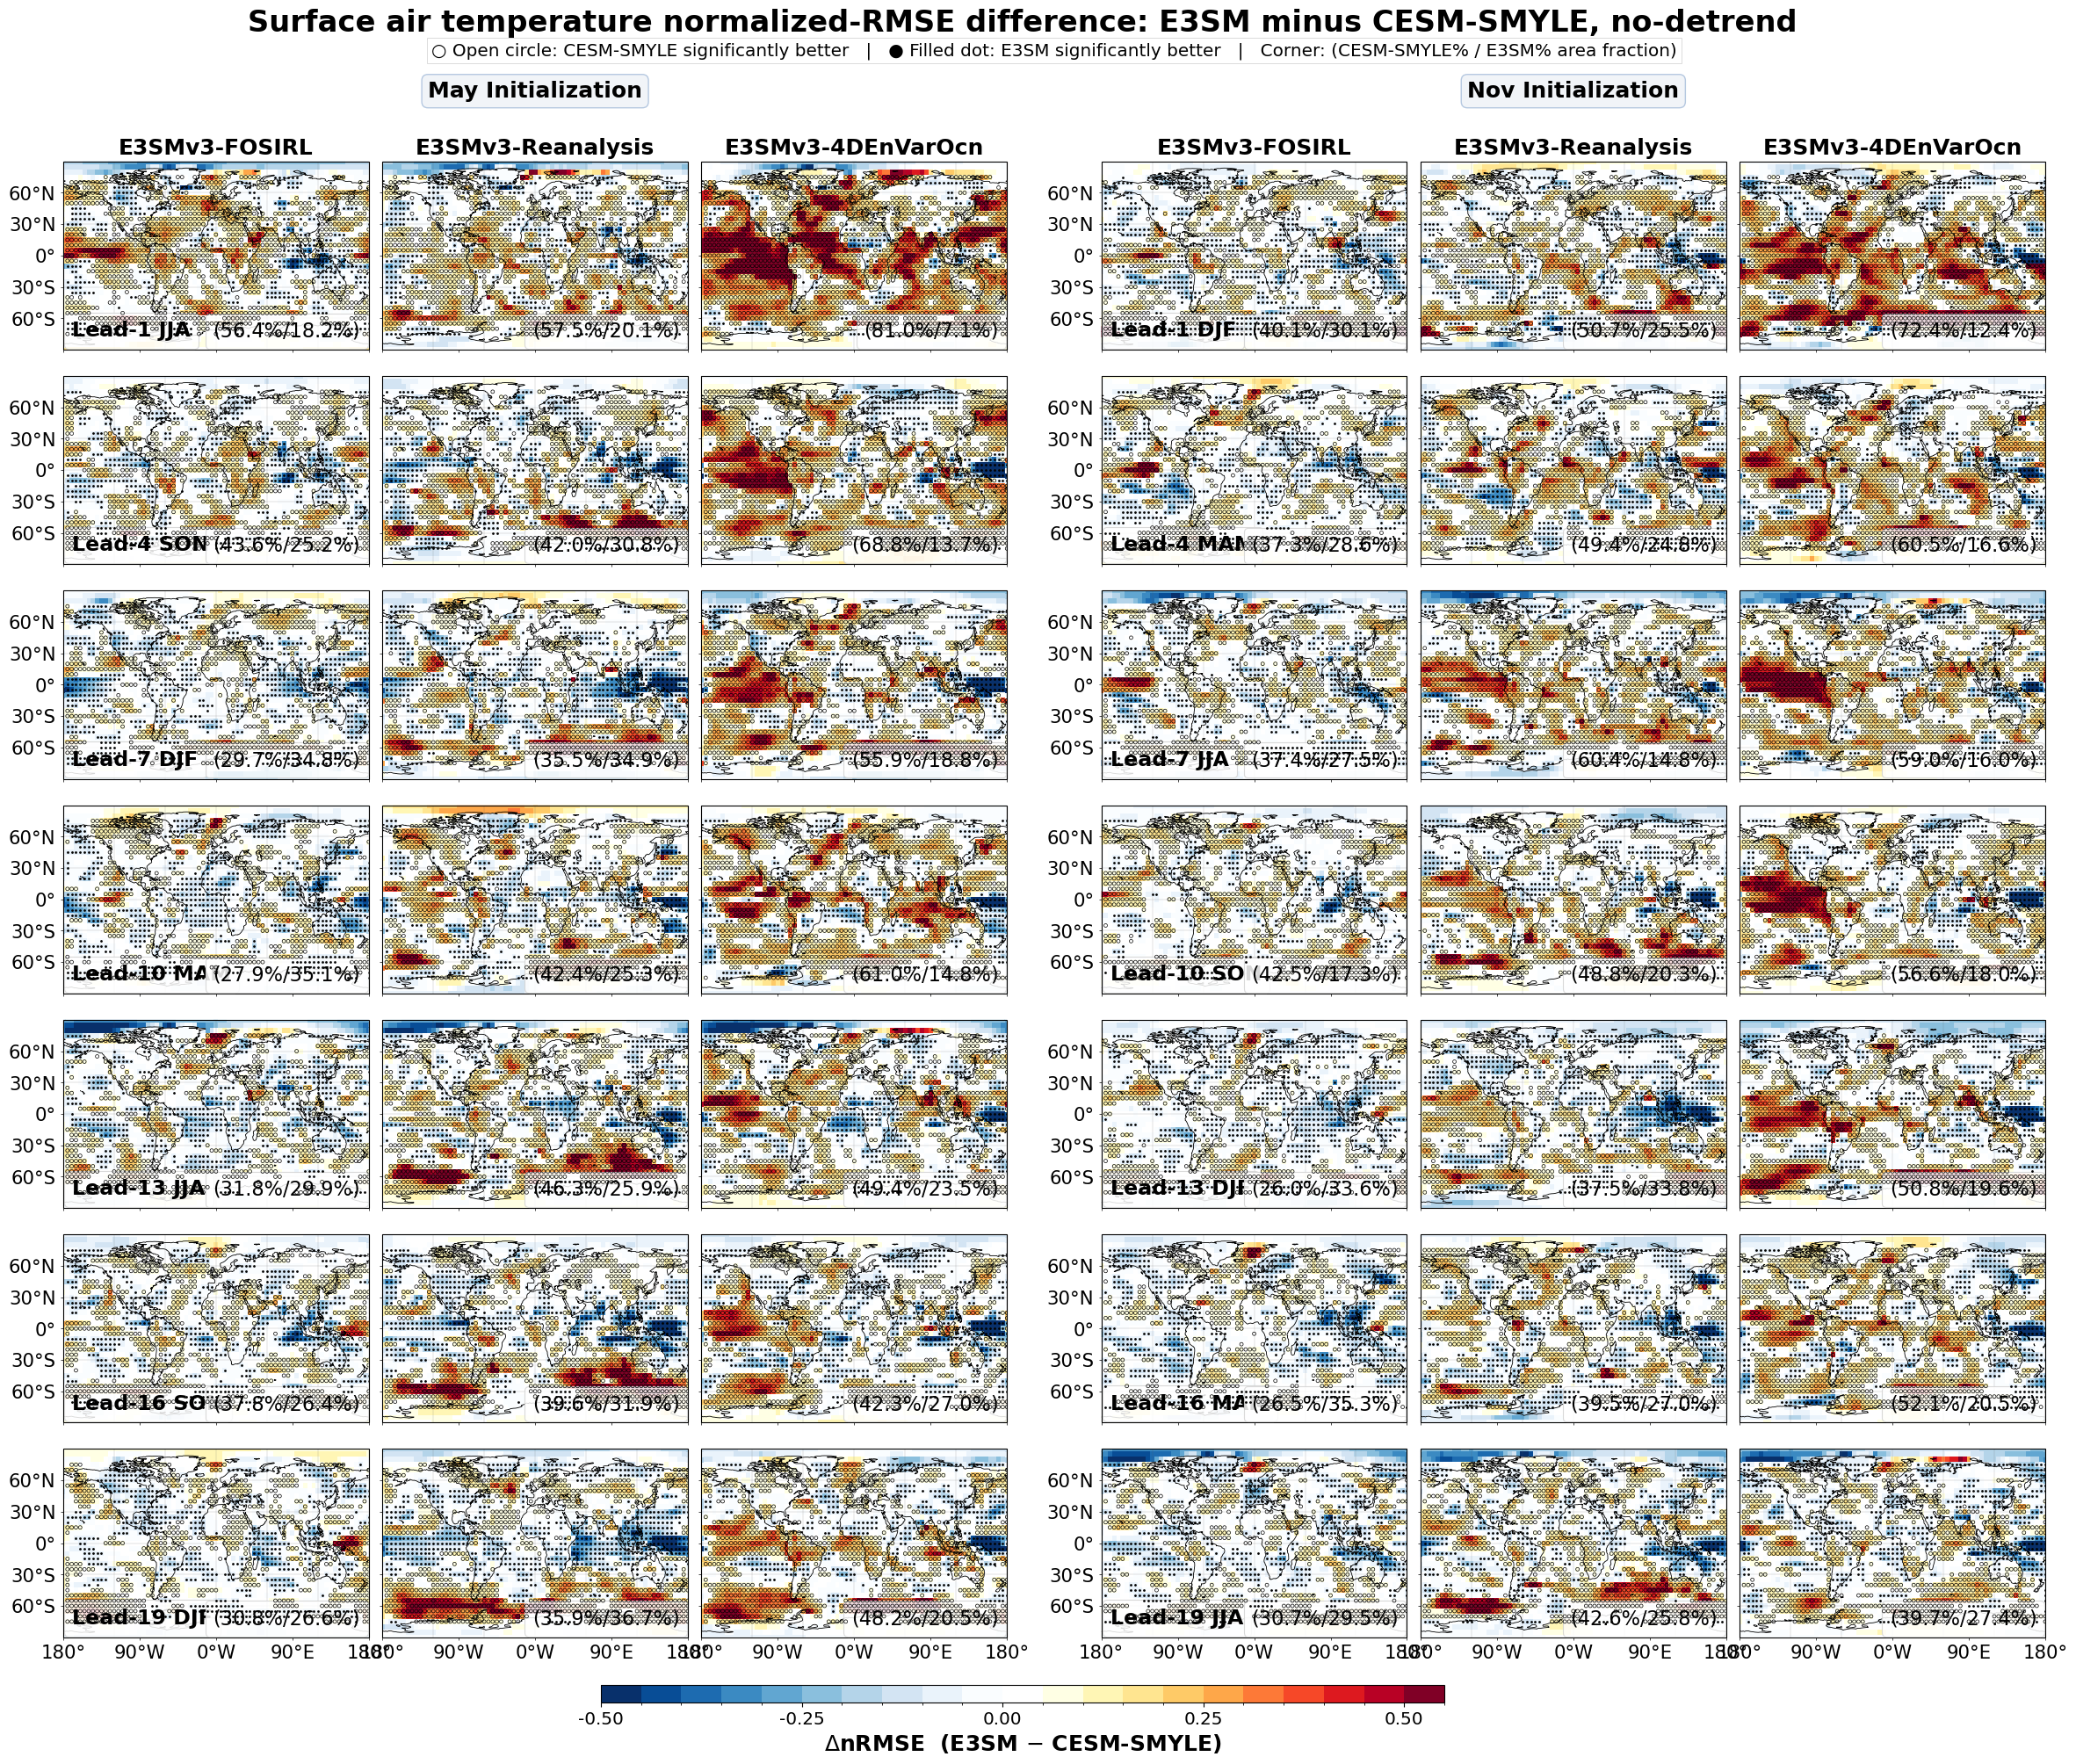

CPU times: user 16 s, sys: 2.02 s, total: 18 s
Wall time: 16.8 s


In [97]:
%%time
# =============================================================================
# Setup parameters: Normalized-RMSE difference layout and styling
# =============================================================================
# Typography & font sizes
compare_fontz = 18
compare_panel_title_size = compare_fontz
compare_section_title_size = compare_fontz * 1.0
compare_lead_badge_size = compare_fontz * 0.95
compare_score_badge_size = compare_fontz * 0.90
compare_lat_lon_label_size = compare_fontz * 0.85
compare_colorbar_label_size = compare_fontz
compare_colorbar_tick_size = compare_fontz * 0.8
compare_suptitle_size = compare_fontz * 1.35
compare_legend_font_size = compare_fontz * 0.8
compare_fweight = "bold"

# Figure geometry and resolution
fig_width = 24.0
fig_height = 20.0
dpi = globals().get("dpi", 300)
suptitle_y = 0.982

# GridSpec spacing and multi-column group partition
gs_top = 0.895
gs_bottom = 0.055
gs_left = 0.045
gs_right = 0.985
gs_hspace = 0.14
gs_wspace = 0.05
middle_spacer_ratio = 0.22

# Map coordinate ticks and gridlines
lon_ticks = [-180, -90, 0, 90, 180]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"
coastline_linewidth = 0.6
latlim = 80

# Significance marker and stippling controls
symclr = "black"
marker_stride = 1
open_marker_size = 8
filled_marker_size = 4
marker_linewidth = 0.5

# Significance legend header banner
legend_x = 0.515
legend_y = 0.958
legend_bbox = dict(boxstyle="square,pad=0.25", facecolor="#ffffff", edgecolor="#cccccc", alpha=0.8, linewidth=0.6)

# Group header banners (May and November initialization)
banner_y = 0.935
banner_bbox = dict(boxstyle="round,pad=0.28", facecolor="#f0f4f8", edgecolor="#b0c4de", alpha=0.92, linewidth=1.0)

# Subplot badge styling
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)

# Colorbar placement and level configuration
colorbar_axes = [0.30, 0.018, 0.40, 0.010]
colorbar_orientation = "horizontal"
# Fallback field-specific normalized-RMSE difference levels if not in globals
if "nrmse_diff_levels" not in globals():
    DIFF_COLORBAR_CONFIG = {
        "TREFHT": {"levels": np.arange(-0.5, 0.5 + 0.05, 0.05), "ticks": [-0.5, -0.25, 0.0, 0.25, 0.5], "decimals": 2},
        "PRECT": {"levels": np.arange(-0.5, 0.5 + 0.05, 0.05), "ticks": [-0.5, -0.25, 0.0, 0.25, 0.5], "decimals": 2},
        "PSL": {"levels": np.arange(-0.6, 0.6 + 0.1, 0.1), "ticks": [-0.6, -0.3, 0.0, 0.3, 0.6], "decimals": 1},
    }
    _diff_cfg = globals().get("MAP_COLORBAR_CONFIG", {}).get("normalized_rmse_difference", {}).get(field) or DIFF_COLORBAR_CONFIG.get(field, DIFF_COLORBAR_CONFIG["PSL"])
    nrmse_diff_levels = np.asarray(_diff_cfg["levels"], dtype=float)
    nrmse_diff_ticks = np.asarray(_diff_cfg["ticks"], dtype=float)
    nrmse_diff_decimals = int(_diff_cfg["decimals"])

diff_level_steps = np.diff(nrmse_diff_levels)
cmin = float(nrmse_diff_levels[0])
cmax = float(nrmse_diff_levels[-1])
ci = float(diff_level_steps[0])
nlevs = int(round((cmax - cmin) / ci)) + 1
clevs = np.arange(cmin, cmax + ci, ci)
colorbar_ticks = nrmse_diff_ticks
colorbar_tick_decimals = nrmse_diff_decimals

# Season & month naming
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}

# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from cartopy.util import add_cyclic_point
from esp_lab.utils import colormap_utils as mycolors
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText

def seasonal_label(init_month, lead):
    center_month = ((init_month + lead - 2) % 12) + 1
    return season_names[((center_month % 12) // 3)]

compare_init_months_plot = sorted(
    set(compare_init_months)
    & set(smyle_compare_skill_by_case_month[E3SM_REFERENCE_CASE])
)
if not compare_init_months_plot:
    raise RuntimeError(
        "No common initialization months are available. Run the preceding "
        "finite-ensemble comparison cell first."
    )
print("Plotting initialization months:", compare_init_months_plot)

# Retain only cases that can be compared in every requested initialization
# section. This keeps the May and November column groups symmetric.
available_compare_cases = []
for case_key in E3SM_COMPARE_CASES:
    has_all_months = all(
        m in smyle_compare_skill_by_case_month.get(case_key, {})
        and m in e3sm_compare_skill_by_case_month.get(case_key, {})
        and m in rmse_significance_by_case_month.get(case_key, {})
        for m in compare_init_months_plot
    )
    if has_all_months:
        available_compare_cases.append(case_key)
    else:
        print(f"Skipping {case_key}: incomplete initialization-month comparison data")

if not available_compare_cases:
    raise RuntimeError("No E3SM cases have complete data for the comparison figure.")

skilldiff_by_case_month = {
    case_key: {
        m: (
            e3sm_compare_skill_by_case_month[case_key][m]
            - smyle_compare_skill_by_case_month[case_key][m].mean("iteration")
        )
        for m in compare_init_months_plot
    }
    for case_key in available_compare_cases
}

first_case = available_compare_cases[0]
first_month = compare_init_months_plot[0]
candidate_leads = smyle_compare_skill_by_case_month[first_case][first_month].L.values
plot_leads = [
    int(lead) for lead in candidate_leads
    if all(
        bool(skilldiff_by_case_month[case_key][m].rmse.sel(L=lead).notnull().any())
        for m in compare_init_months_plot
        for case_key in available_compare_cases
    )
]
if not plot_leads:
    raise RuntimeError("No common finite seasonal RMSE leads are available.")

area = destgrid.area
lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)
lons = destgrid.lon.values
lats = destgrid.lat.values

cmap_obj = mycolors.blue2red_cmap(nlevs)
norm = BoundaryNorm(clevs, ncolors=cmap_obj.N, clip=True)

nrows = len(plot_leads)
ncases = len(available_compare_cases)

# Support multi-month comparison with dedicated spacer column between groups
if len(compare_init_months_plot) == 2 and ncases == 3:
    ncols = 7
    width_ratios = [1, 1, 1, middle_spacer_ratio, 1, 1, 1]
    month_col_offsets = {
        compare_init_months_plot[0]: 0,
        compare_init_months_plot[1]: 4,
    }
else:
    ncols = len(compare_init_months_plot) * ncases
    width_ratios = [1] * ncols
    month_col_offsets = {
        m: idx * ncases for idx, m in enumerate(compare_init_months_plot)
    }

fig = plt.figure(figsize=(fig_width, fig_height))
detrend_label = "linear-detrend" if detrend else "no-detrend"
subtitle = f"{cfg['plot_name']} normalized-RMSE difference: E3SM minus CESM-SMYLE, {detrend_label}"
fig.suptitle(subtitle, fontsize=compare_suptitle_size, fontweight=compare_fweight, y=suptitle_y)

fig.text(
    legend_x, legend_y,
    "○ Open circle: CESM-SMYLE significantly better   |   ● Filled dot: E3SM significantly better   |   Corner: (CESM-SMYLE% / E3SM% area fraction)",
    ha="center", va="center", fontsize=compare_legend_font_size, fontweight="medium",
    bbox=legend_bbox
)

gs = fig.add_gridspec(
    nrows=nrows, ncols=ncols,
    width_ratios=width_ratios,
    top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
    hspace=gs_hspace, wspace=gs_wspace,
)

top_axes_by_month = {m: [] for m in compare_init_months_plot}
cntr = None

for i, lead in enumerate(plot_leads):
    for compare_init_month in compare_init_months_plot:
        col_offset = month_col_offsets[compare_init_month]
        for c_idx, case_key in enumerate(available_compare_cases):
            grid_col = col_offset + c_idx
            ax = fig.add_subplot(gs[i, grid_col], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            case_label = E3SM_CASES[case_key].get("display_name", case_key)
            if i == 0:
                ax.set_title(case_label, fontsize=compare_panel_title_size, fontweight=compare_fweight, pad=6)
                top_axes_by_month[compare_init_month].append(ax)

            skilldiff = skilldiff_by_case_month[case_key][compare_init_month]
            significance = rmse_significance_by_case_month[case_key][compare_init_month]
            da = skilldiff.rmse.sel(L=lead)
            valid = da.notnull()

            dat_cyc, lon_cyc = add_cyclic_point(da.values, coord=lons)
            cntr = ax.pcolormesh(lon_cyc, lats, dat_cyc, shading="nearest", cmap=cmap_obj, norm=norm, rasterized=True, transform=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE, linewidth=coastline_linewidth)

            # Significance markers
            bsmyle_better = (significance["right_better"].sel(L=lead) == 1) & valid
            nbetter = rmse_utils.valid_area_weighted_fraction(bsmyle_better, valid=valid, area=area, latitude_limit=latlim)
            disp_mask = np.asarray(bsmyle_better)[::marker_stride, ::marker_stride]
            disp_lon = lon2d[::marker_stride, ::marker_stride]
            disp_lat = lat2d[::marker_stride, ::marker_stride]
            disp_mask &= abs(disp_lat) < latlim
            ax.scatter(disp_lon[disp_mask], disp_lat[disp_mask], facecolor="none", edgecolor=symclr, s=open_marker_size, linewidth=marker_linewidth, zorder=10)

            e3sm_better = (significance["left_better"].sel(L=lead) == 1) & valid
            nworse = rmse_utils.valid_area_weighted_fraction(e3sm_better, valid=valid, area=area, latitude_limit=latlim)
            disp_mask = np.asarray(e3sm_better)[::marker_stride, ::marker_stride]
            disp_mask &= abs(disp_lat) < latlim
            ax.scatter(disp_lon[disp_mask], disp_lat[disp_mask], facecolor=symclr, edgecolor=symclr, s=filled_marker_size, linewidth=0, zorder=10)

            # Axis tick hygiene: latitude only on first column of each group, longitude only on bottom row
            is_left = (c_idx == 0)
            is_bottom = (i == nrows - 1)
            ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
            ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(
                labelsize=compare_lat_lon_label_size, length=lat_lon_tick_length, width=lat_lon_tick_width,
                top=False, right=False,
                labelleft=is_left, labelbottom=is_bottom,
            )
            ax.gridlines(crs=ccrs.PlateCarree(), linewidth=gridline_width, color=gridline_color, alpha=gridline_alpha, linestyle=gridline_style, draw_labels=False)

            # Lead badge in lower-left corner of first column in each group
            if c_idx == 0:
                badge_text = f"Lead-{lead - 2} {seasonal_label(compare_init_month, lead)}"
                b = AnchoredText(badge_text, loc="lower left", prop=dict(size=compare_lead_badge_size, weight="bold", family="sans-serif"),
                                 frameon=True, pad=badge_pad, borderpad=badge_borderpad)
                b.patch.set(**badge_bbox)
                ax.add_artist(b)

            # Score fraction in lower-right corner of each panel
            score_text = f"({nbetter * 100:3.1f}%/{nworse * 100:3.1f}%)"
            sb = AnchoredText(score_text, loc="lower right", prop=dict(size=compare_score_badge_size, weight="medium", family="sans-serif"),
                              frameon=True, pad=badge_pad, borderpad=badge_borderpad)
            sb.patch.set(**badge_bbox)
            ax.add_artist(sb)

# Group header banners above each initialization month group
fig.canvas.draw()
for compare_init_month, axes_for_month in top_axes_by_month.items():
    if not axes_for_month:
        continue
    left = axes_for_month[0].get_position().x0
    right = axes_for_month[-1].get_position().x1
    init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}").title()
    fig.text(
        0.5 * (left + right), banner_y, f"{init_label} Initialization",
        ha="center", va="center",
        fontsize=compare_section_title_size, fontweight=compare_fweight,
        bbox=banner_bbox,
    )

# Shared horizontal colorbar at the bottom
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(colorbar_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{colorbar_tick_decimals}f")
)
cbar.set_label(r"${\Delta}$nRMSE  (E3SM $-$ CESM-SMYLE)", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

skilldiff_figname = FIGURE_FILENAMES["difference"]
skilldiff_figpath = FIGURE_OUTDIR / skilldiff_figname
mov.save_figure(
    fig, skilldiff_figpath,
    mode="",
    metric="leadtime_rmse_diff",
    title=f"Leadtime RMSE Difference: {field}, multi-E3SM comparison",
    caption=(
        "Normalized-RMSE differences between E3SM hindcasts and "
        "CESM-SMYLE ensembles, grouped by May and November initialization"
    ),
    dpi=dpi,
)
print("Saved figure:", skilldiff_figpath)
plt.show()

# Backward-compatible reference-case difference dictionary.
e3sm_compare_skilldiff_by_month = {
    m: e3sm_compare_skill_by_case_month[E3SM_REFERENCE_CASE][m] - smyle_compare_skill_by_case_month[E3SM_REFERENCE_CASE][m].mean("iteration")
    for m in compare_init_months_plot
}

## Resource cleanup

Close tracked NetCDF datasets and Dask resources after all outputs are written.

In [98]:
for name in ('skill_by_model', 'skill_by_case_month', 'smyle_skill_by_month'):
    for value in globals().get(name, {}).values():
        values = value.values() if isinstance(value, dict) else (value,)
        for dataset in values:
            close = getattr(dataset, 'close', None)
            if close is not None:
                close()
close_notebook_resources(globals())
plt.close('all')
print('Closed RMSE workflow datasets, figures, and Dask resources.')


Closed RMSE workflow datasets, figures, and Dask resources.
